# MixUp Regressor-Modelle auf dem Test-Split und Lebenshilfe-Datensatz evaluieren

1. **Variante A (Statisch):** Modell mit festem Mischen/Shuffling in `__init__` ($p_{\text{dynamic}}=0.0$).

4. **Variante D (Hybrid + Cyclic LR):** Modell mit Hybrid-Mischen und Cosinus-Lernratenscheduling.


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, "data")) and os.path.exists(os.path.join(p, "results")):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser("~/Documents/Master Thesis"))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.dpi": 150
})


Aktuelles Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


In [2]:
# Evaluationsdaten laden
SUMMARY_CSV = os.path.join(REPO_ROOT, "results/evaluation/mixup_variants_eval.csv")
TEST_PREDS_CSV = os.path.join(REPO_ROOT, "results/evaluation/mixup_variants_test_predictions.csv")
TEST_REG_CSV = os.path.join(REPO_ROOT, "results/evaluation/mixup_variants_test_regression.csv")
LH_PREDS_CSV = os.path.join(REPO_ROOT, "results/evaluation/mixup_variants_lh_predictions.csv")
LH_REG_CSV = os.path.join(REPO_ROOT, "results/evaluation/mixup_variants_lh_regression.csv")
TRAIN_TARGETS_CSV = os.path.join(REPO_ROOT, "results/evaluation/mixup_variants_train_targets.csv")

df_summary = pd.read_csv(SUMMARY_CSV) if os.path.exists(SUMMARY_CSV) else pd.DataFrame()
df_test_preds = pd.read_csv(TEST_PREDS_CSV) if os.path.exists(TEST_PREDS_CSV) else pd.DataFrame()
df_test_reg = pd.read_csv(TEST_REG_CSV) if os.path.exists(TEST_REG_CSV) else pd.DataFrame()
df_lh_preds = pd.read_csv(LH_PREDS_CSV) if os.path.exists(LH_PREDS_CSV) else pd.DataFrame()
df_lh_reg = pd.read_csv(LH_REG_CSV) if os.path.exists(LH_REG_CSV) else pd.DataFrame()
train_targets = pd.read_csv(TRAIN_TARGETS_CSV)["target"].tolist() if os.path.exists(TRAIN_TARGETS_CSV) else None

print(f"Geladene Zusammenfassung: {len(df_summary)} Modelle")
print(f"Geladene Test-Satz-Vorhersagen: {len(df_test_preds)} Sätze")
print(f"Geladene Test-Regressions-Samples: {len(df_test_reg)} Samples")
print(f"Geladene LH-Satz-Vorhersagen: {len(df_lh_preds)} Sätze")
print(f"Geladene LH-Regressions-Samples: {len(df_lh_reg)} Samples")


Geladene Zusammenfassung: 4 Modelle
Geladene Test-Satz-Vorhersagen: 2968 Sätze
Geladene Test-Regressions-Samples: 2560 Samples
Geladene LH-Satz-Vorhersagen: 2236 Sätze
Geladene LH-Regressions-Samples: 1476 Samples


# 1. Auswertung auf dem Test-Split (In-Domain)


In [3]:
# 1.1. Binäre Klassifikationsevaluation auf dem Test-Split (LS = 1.0, AS = 0.0)
test_table_rows = []
for _, row in df_summary.iterrows():
    test_table_rows.append({
        "Modell": row["model"],
        "Ø Lambda (LS)": f"{float(row['test_mean_lambda_ls']):.4f}",
        "Ø Lambda (AS)": f"{float(row['test_mean_lambda_as']):.4f}",
        "Accuracy (Schwelle 0.5)": f"{float(row['test_accuracy']) * 100:.2f}%",
        "Balanced Acc": f"{float(row['test_balanced_acc']) * 100:.2f}%",
        "MAE (Target 1/0)": f"{float(row['test_class_mae']):.4f}"
    })

df_test_metrics = pd.DataFrame(test_table_rows)
print("Klassifikationsergebnisse auf dem Test-Split (Reine Sätze):")
display(df_test_metrics)


Klassifikationsergebnisse auf dem Test-Split (Reine Sätze):


,Modell,Ø Lambda (LS),Ø Lambda (AS),Accuracy (Schwelle 0.5),Balanced Acc,MAE (Target 1/0)
0,Variante A (Statisch),0.7771,0.0749,95.42%,94.79%,0.1367
1,Variante B (Dynamisch),0.8021,0.0672,96.50%,96.08%,0.1218
2,Variante C (Hybrid),0.8009,0.0823,96.36%,95.92%,0.1311
3,Variante D (Hybrid + Cyclic),0.7987,0.0855,96.36%,95.87%,0.1339


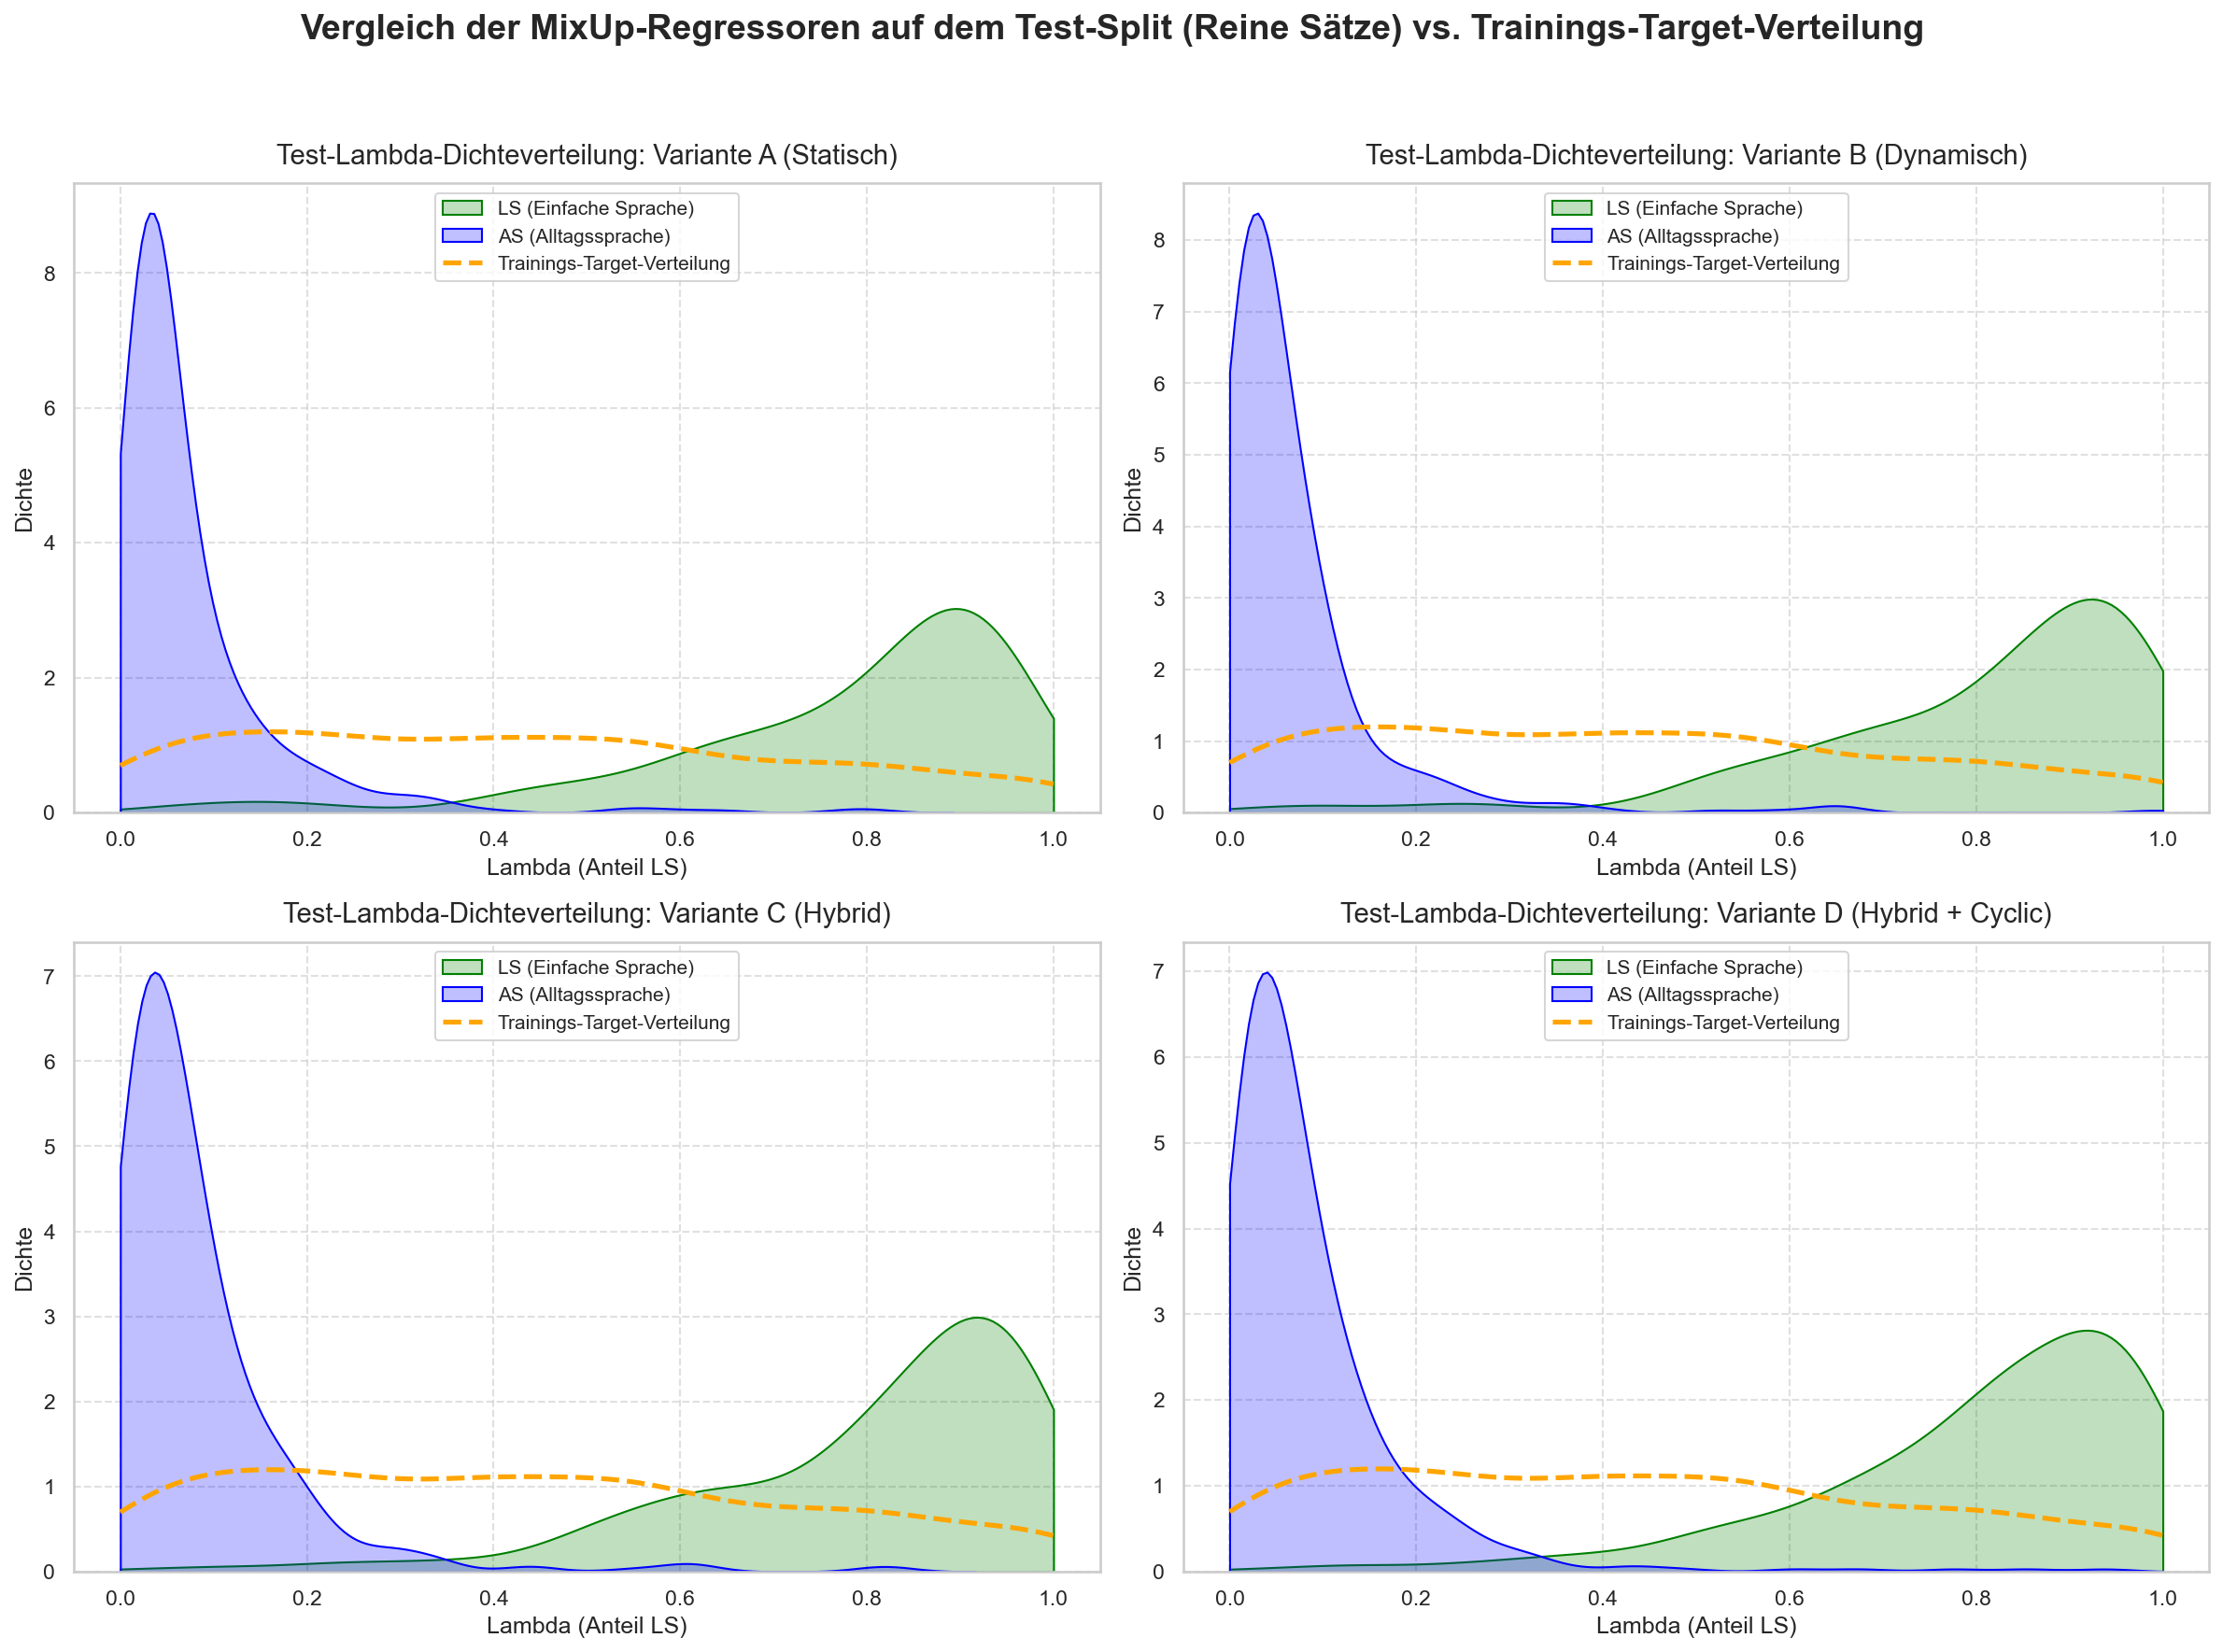

In [4]:
# 1.2. KDE-Plots (Dichteverteilungen) für die Klassifikation auf dem Test-Split
models_list = df_summary["model"].tolist() if not df_summary.empty else df_test_preds["model"].unique().tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models_list):
    sub_ls = df_test_preds[(df_test_preds["model"] == model_name) & (df_test_preds["text_type"] == "LS")]["predicted_lambda"]
    sub_as = df_test_preds[(df_test_preds["model"] == model_name) & (df_test_preds["text_type"] == "AS")]["predicted_lambda"]
    
    if len(sub_ls) > 0 and len(sub_as) > 0:
        sns.kdeplot(sub_ls, fill=True, color="green", label="LS (Einfache Sprache)", ax=axes[i], clip=(0.0, 1.0))
        sns.kdeplot(sub_as, fill=True, color="blue", label="AS (Alltagssprache)", ax=axes[i], clip=(0.0, 1.0))
    
    if train_targets is not None:
        sns.kdeplot(train_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Trainings-Target-Verteilung", ax=axes[i], clip=(0.0, 1.0))
        
    axes[i].set_title(f"Test-Lambda-Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren auf dem Test-Split (Reine Sätze) vs. Trainings-Target-Verteilung", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plot_test_kde = os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_test_classification_kde.png")
os.makedirs(os.path.dirname(plot_test_kde), exist_ok=True)
plt.savefig(plot_test_kde, dpi=300)
plt.show()


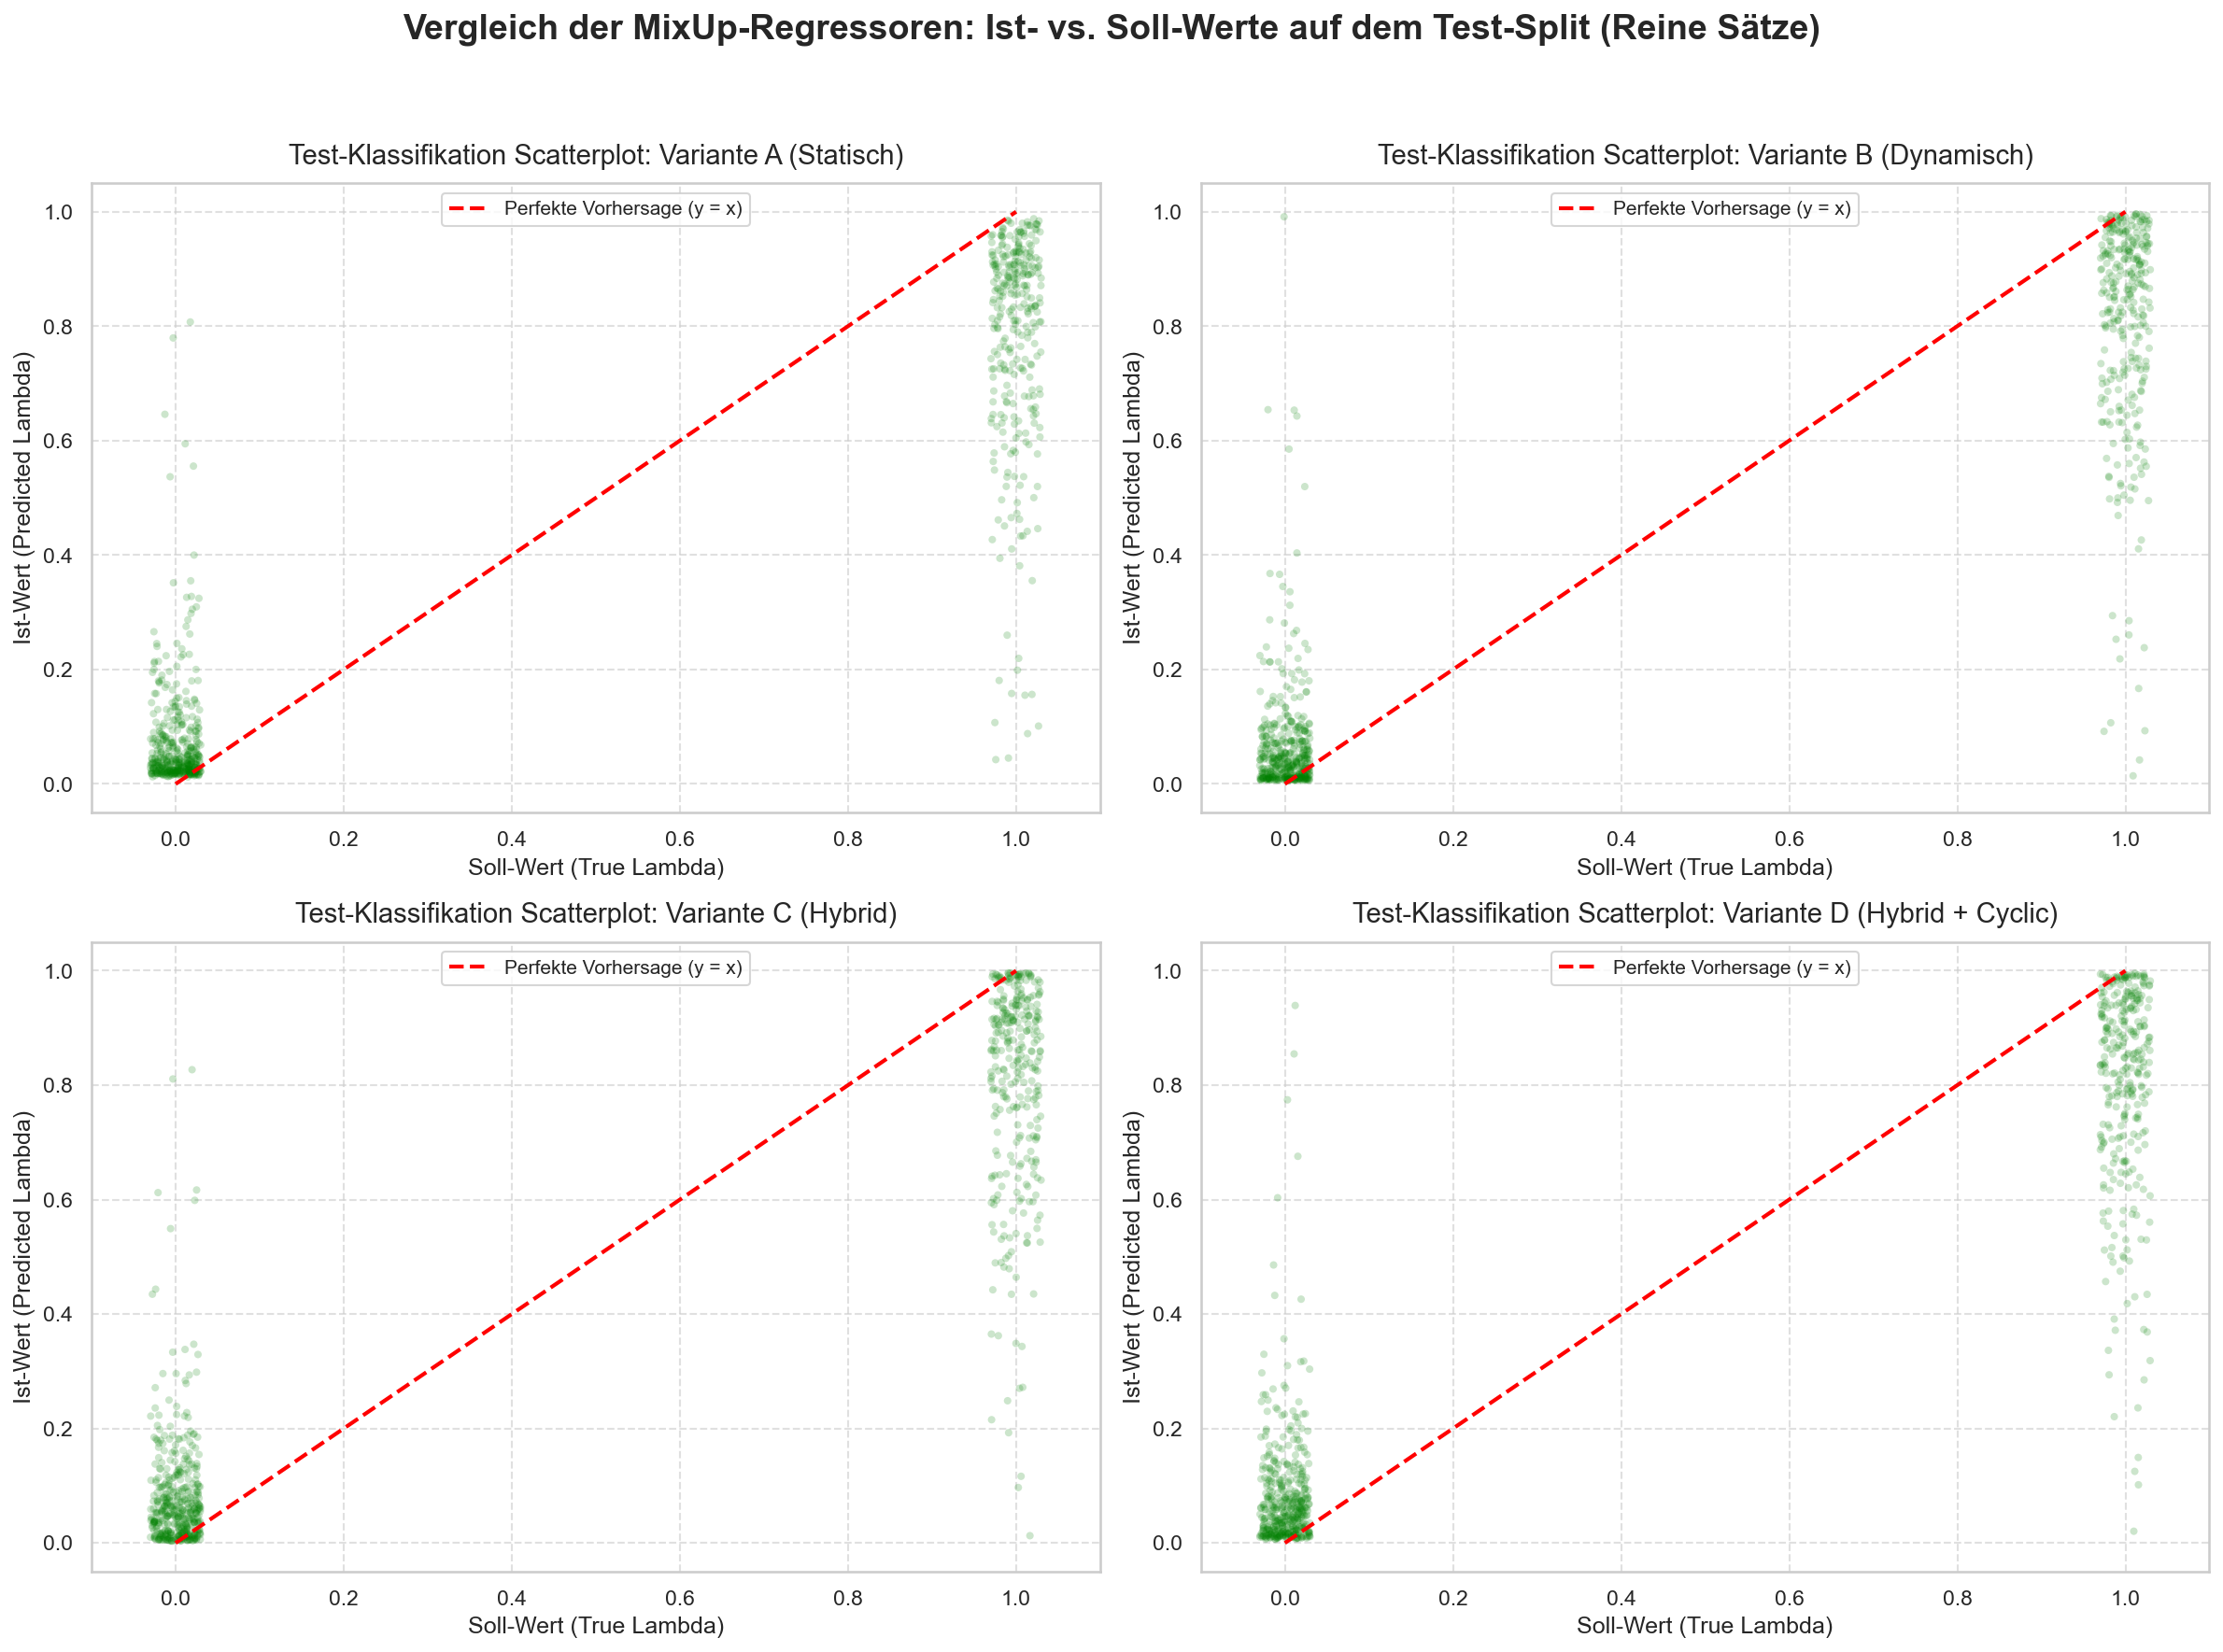

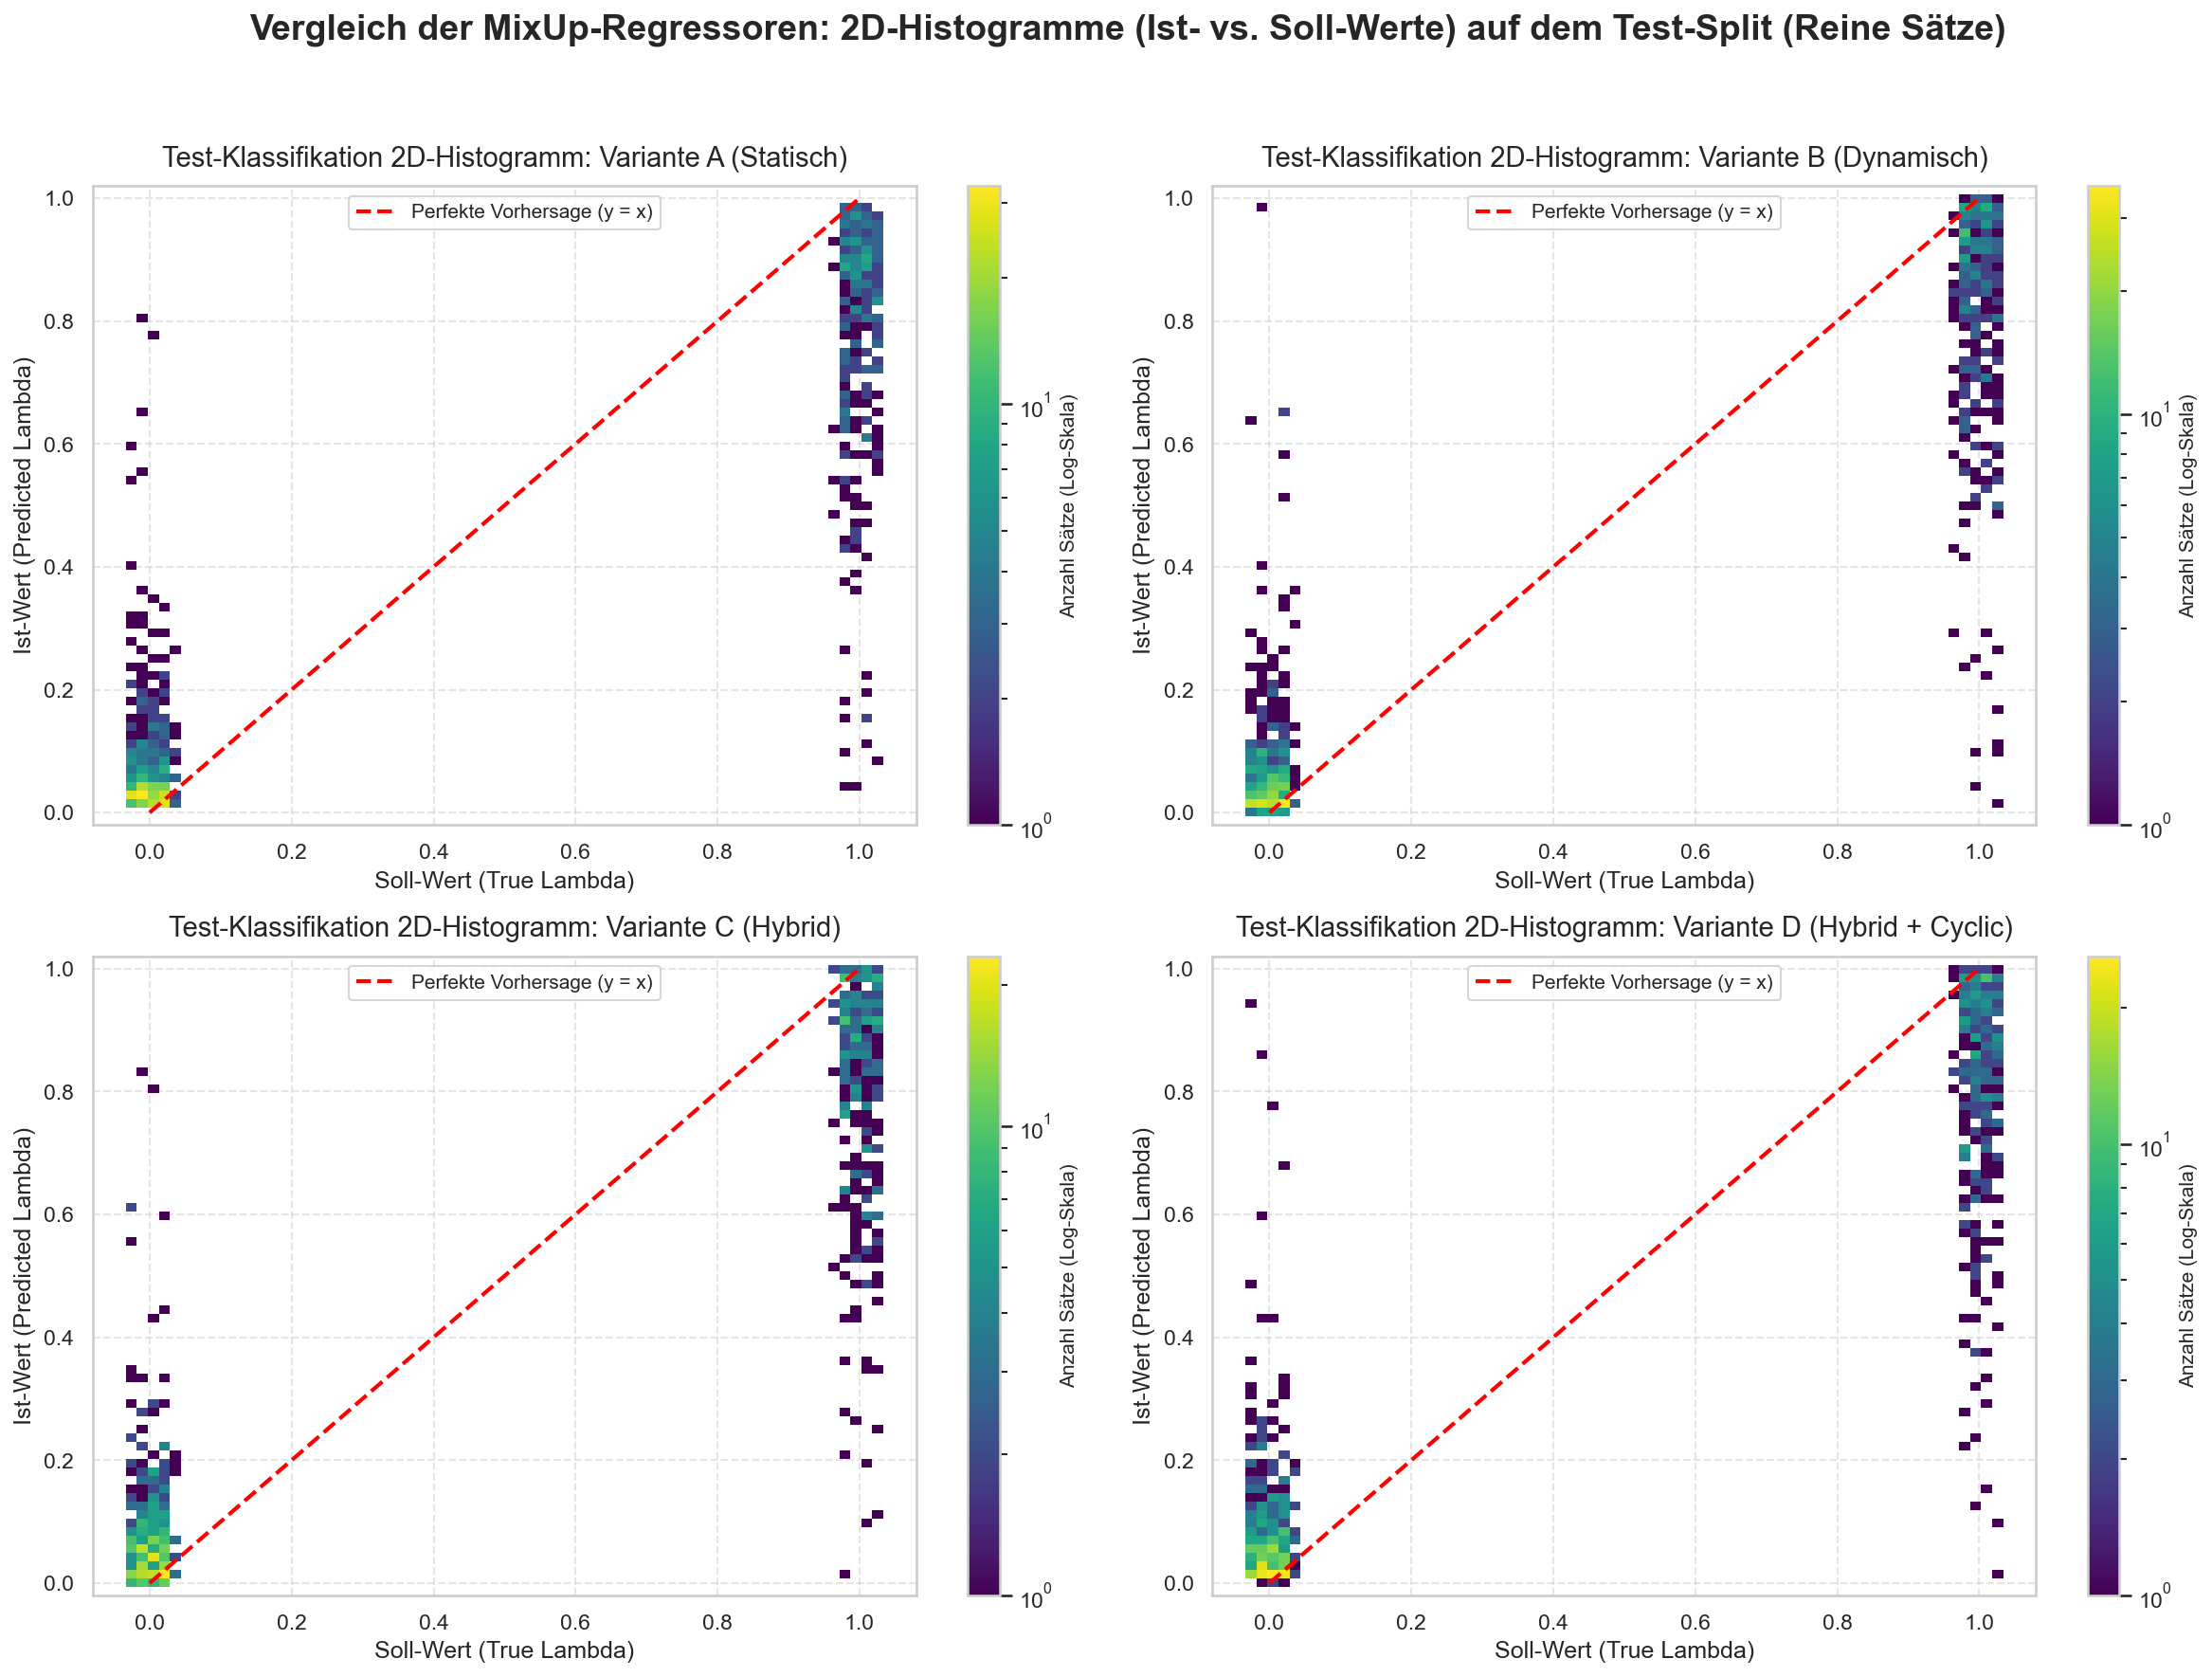

In [5]:
# 1.2.5. Scatterplots (Ist- vs. Soll-Wert) für die Klassifikation (reine Sätze) auf dem Test-Split
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models_list):
    sub = df_test_preds[df_test_preds["model"] == model_name]
    if len(sub) > 0:
        jitter = np.random.uniform(-0.03, 0.03, len(sub))
        axes[i].scatter(sub["true_label"] + jitter, sub["predicted_lambda"], alpha=0.2, color="green", edgecolors="none", s=15)
    
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    axes[i].set_title(f"Test-Klassifikation Scatterplot: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.1, 1.1)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Ist- vs. Soll-Werte auf dem Test-Split (Reine Sätze)", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_test_classification_scatterplot.png"), dpi=300)
plt.show()

# 1.2.6. 2D-Histogramme (Ist- vs. Soll-Wert) für die Klassifikation (reine Sätze) auf dem Test-Split
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models_list):
    sub = df_test_preds[df_test_preds["model"] == model_name]
    if len(sub) > 0:
        jitter = np.random.uniform(-0.03, 0.03, len(sub))
        counts, xedges, yedges, im = axes[i].hist2d(
            sub["true_label"] + jitter, sub["predicted_lambda"], bins=75, range=[[-0.08, 1.08], [-0.02, 1.02]],
            cmap="viridis", norm=mcolors.LogNorm(), cmin=1
        )
        cbar = fig.colorbar(im, ax=axes[i])
        cbar.set_label("Anzahl Sätze (Log-Skala)", fontsize=10)
        
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    axes[i].set_title(f"Test-Klassifikation 2D-Histogramm: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.08, 1.08)
    axes[i].set_ylim(-0.02, 1.02)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Vergleich der MixUp-Regressoren: 2D-Histogramme (Ist- vs. Soll-Werte) auf dem Test-Split (Reine Sätze)", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_test_classification_hist2d.png"), dpi=300)
plt.show()


In [6]:
# 1.3. Regressionsevaluation auf dem Test-Split (Mixup / Shuffled)
test_reg_rows = []
for _, row in df_summary.iterrows():
    test_reg_rows.append({
        "Modell": row["model"],
        "Test MSE (Regression)": f"{float(row['test_reg_mse']):.4f}",
        "Test MAE (Regression)": f"{float(row['test_reg_mae']):.4f}"
    })

df_test_reg_metrics = pd.DataFrame(test_reg_rows)
print("Regressionsergebnisse auf dem Test-Split (Mixup):")
display(df_test_reg_metrics)


Regressionsergebnisse auf dem Test-Split (Mixup):


,Modell,Test MSE (Regression),Test MAE (Regression)
0,Variante A (Statisch),0.0279,0.1234
1,Variante B (Dynamisch),0.0267,0.1182
2,Variante C (Hybrid),0.0275,0.1222
3,Variante D (Hybrid + Cyclic),0.0275,0.1221


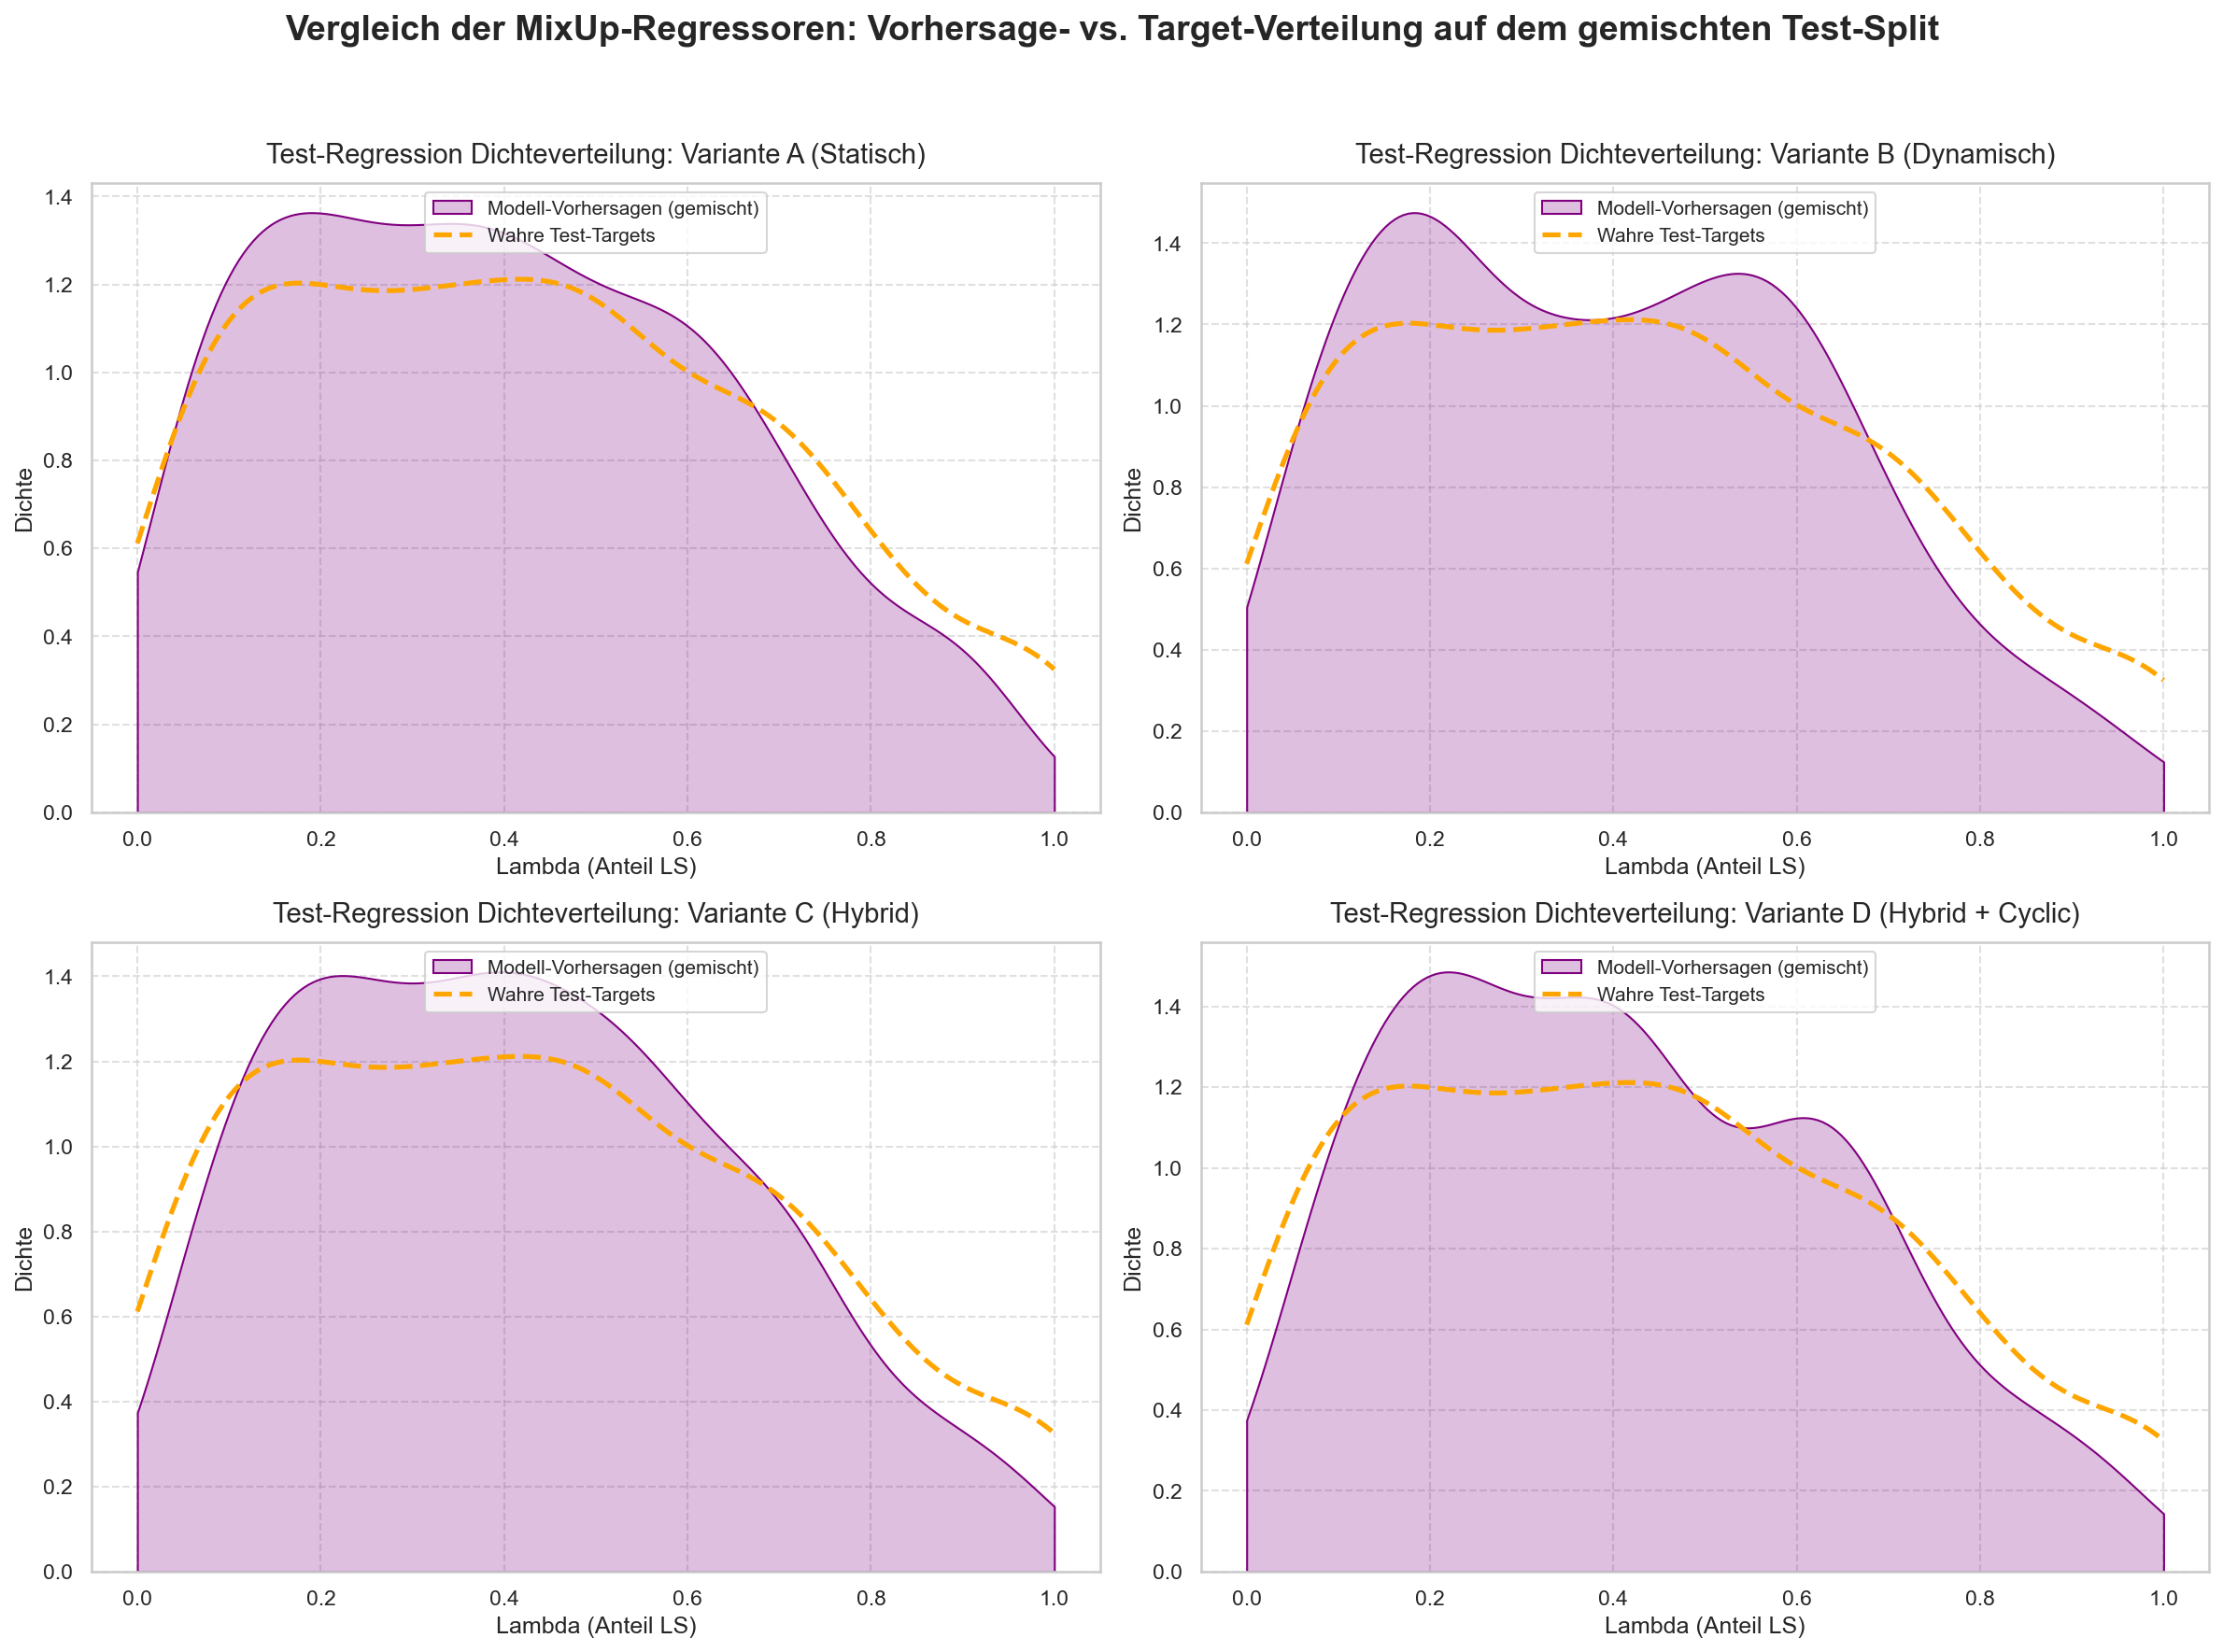

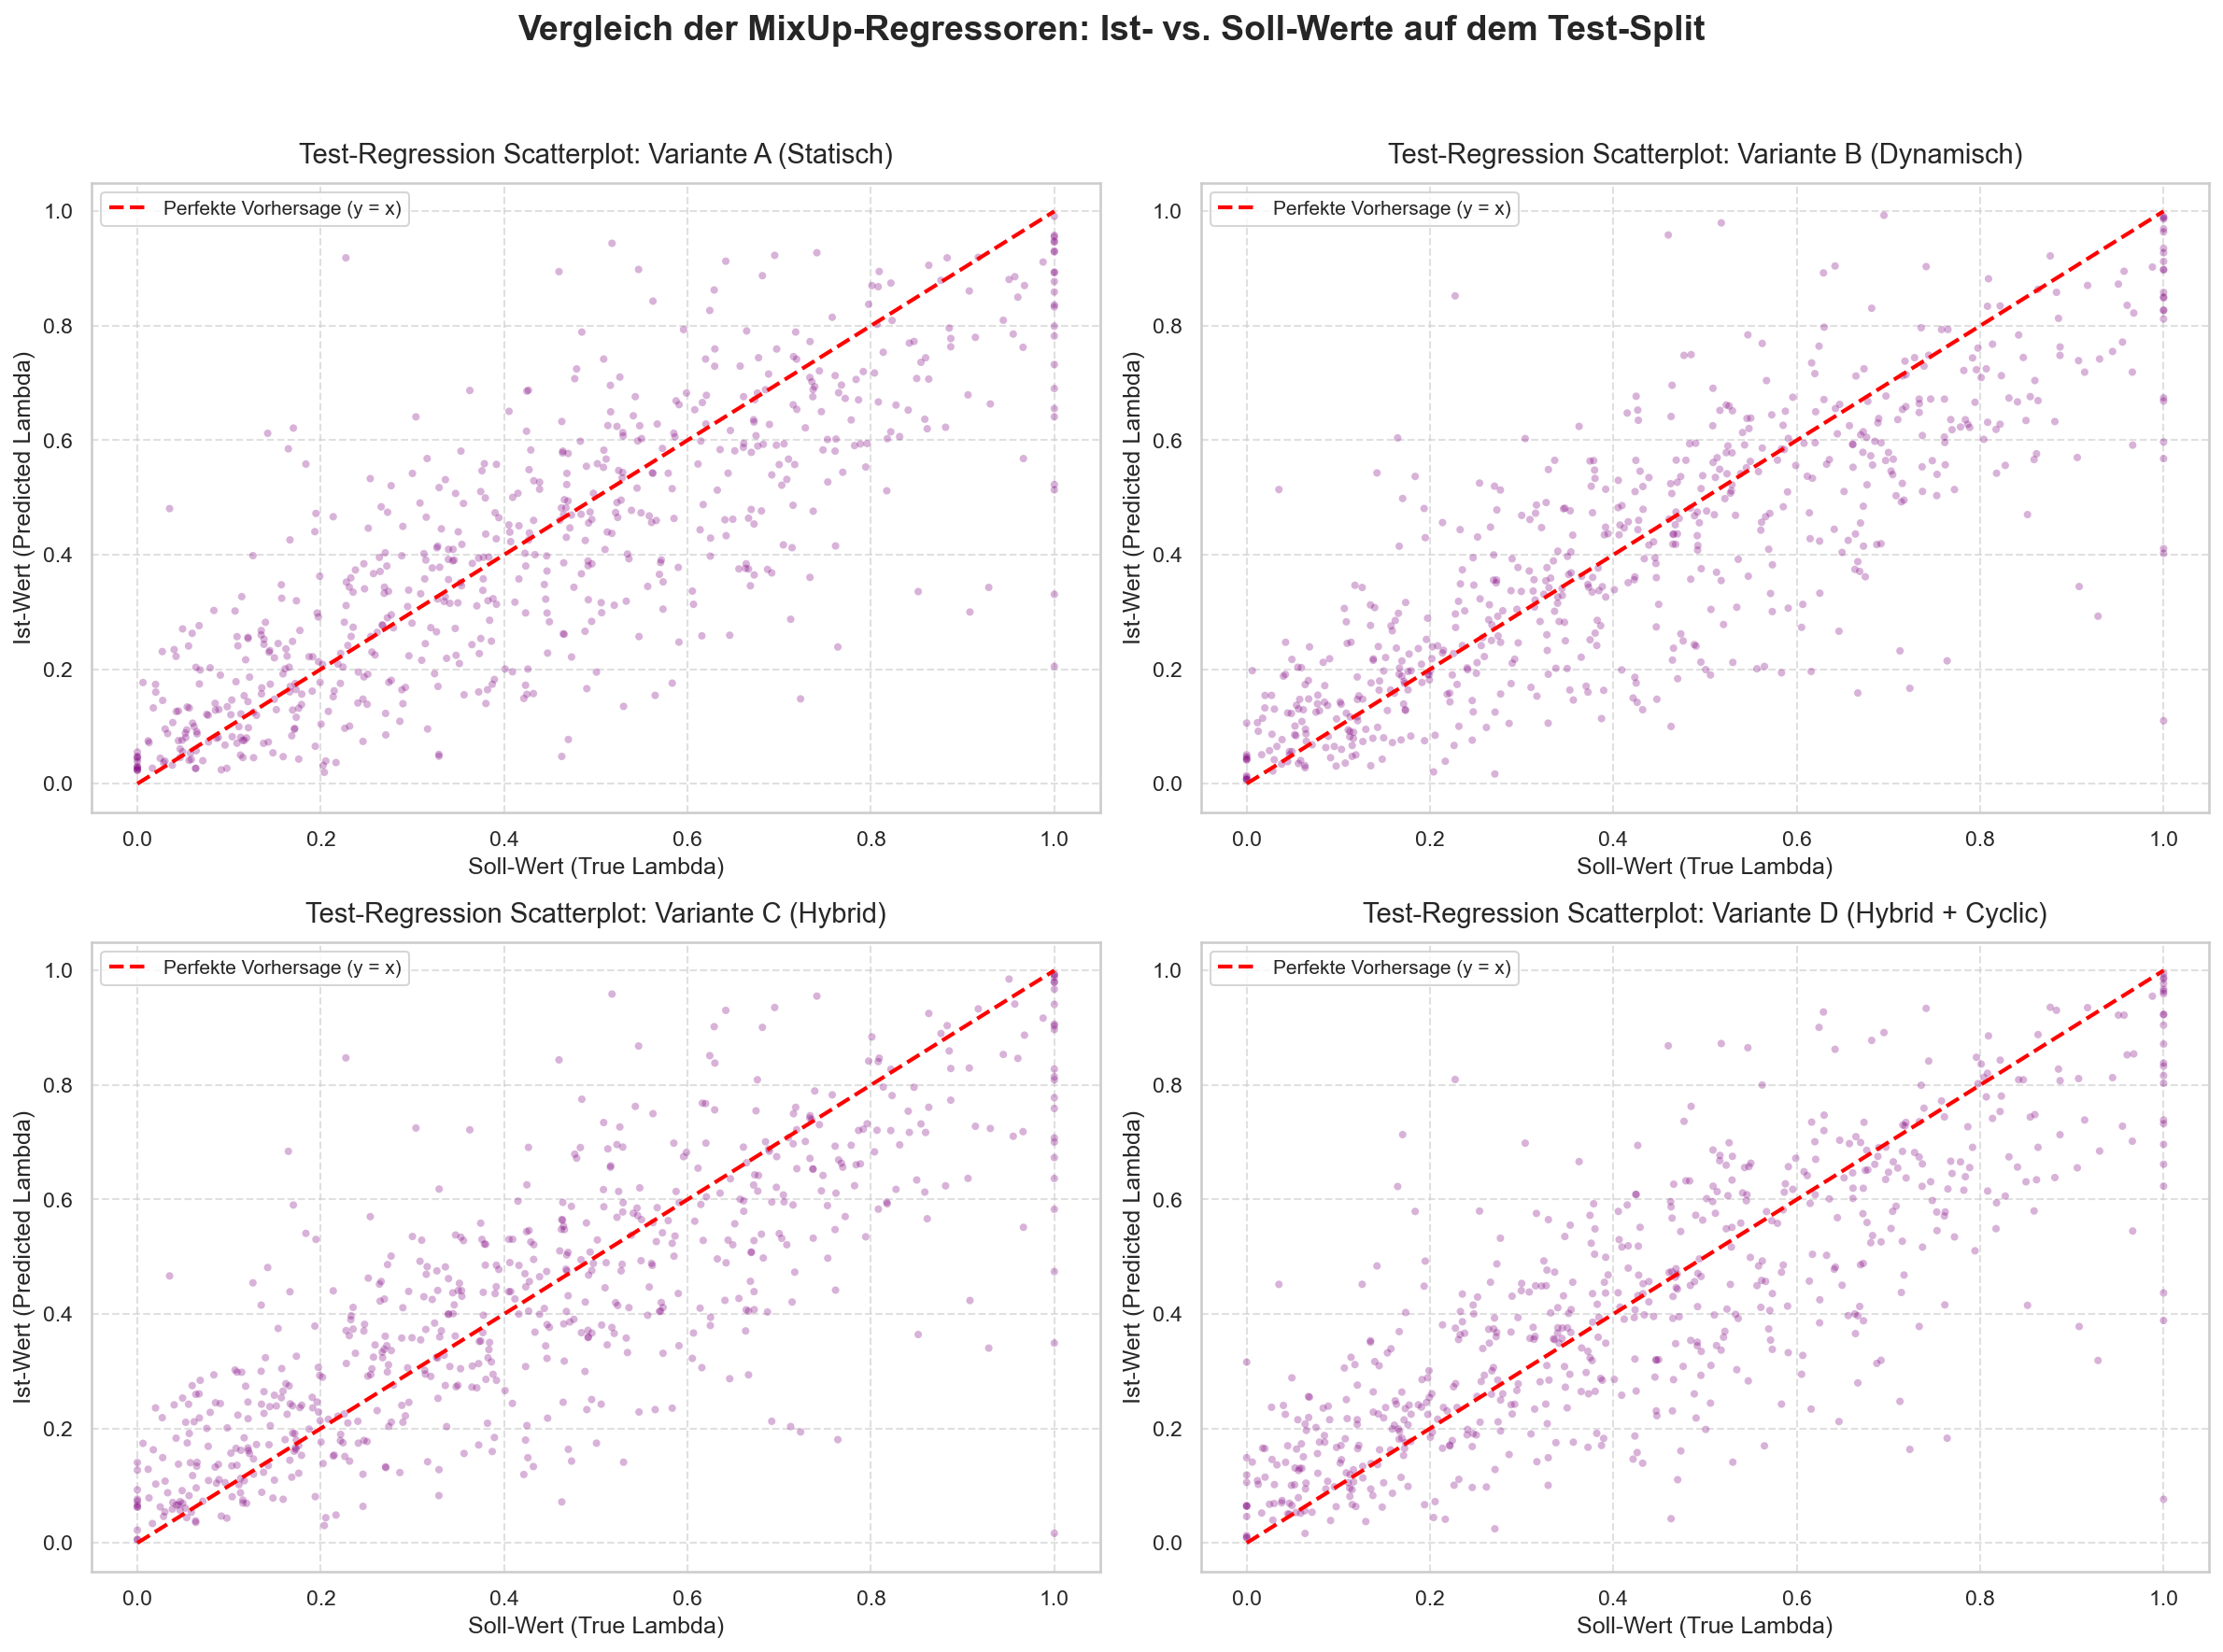

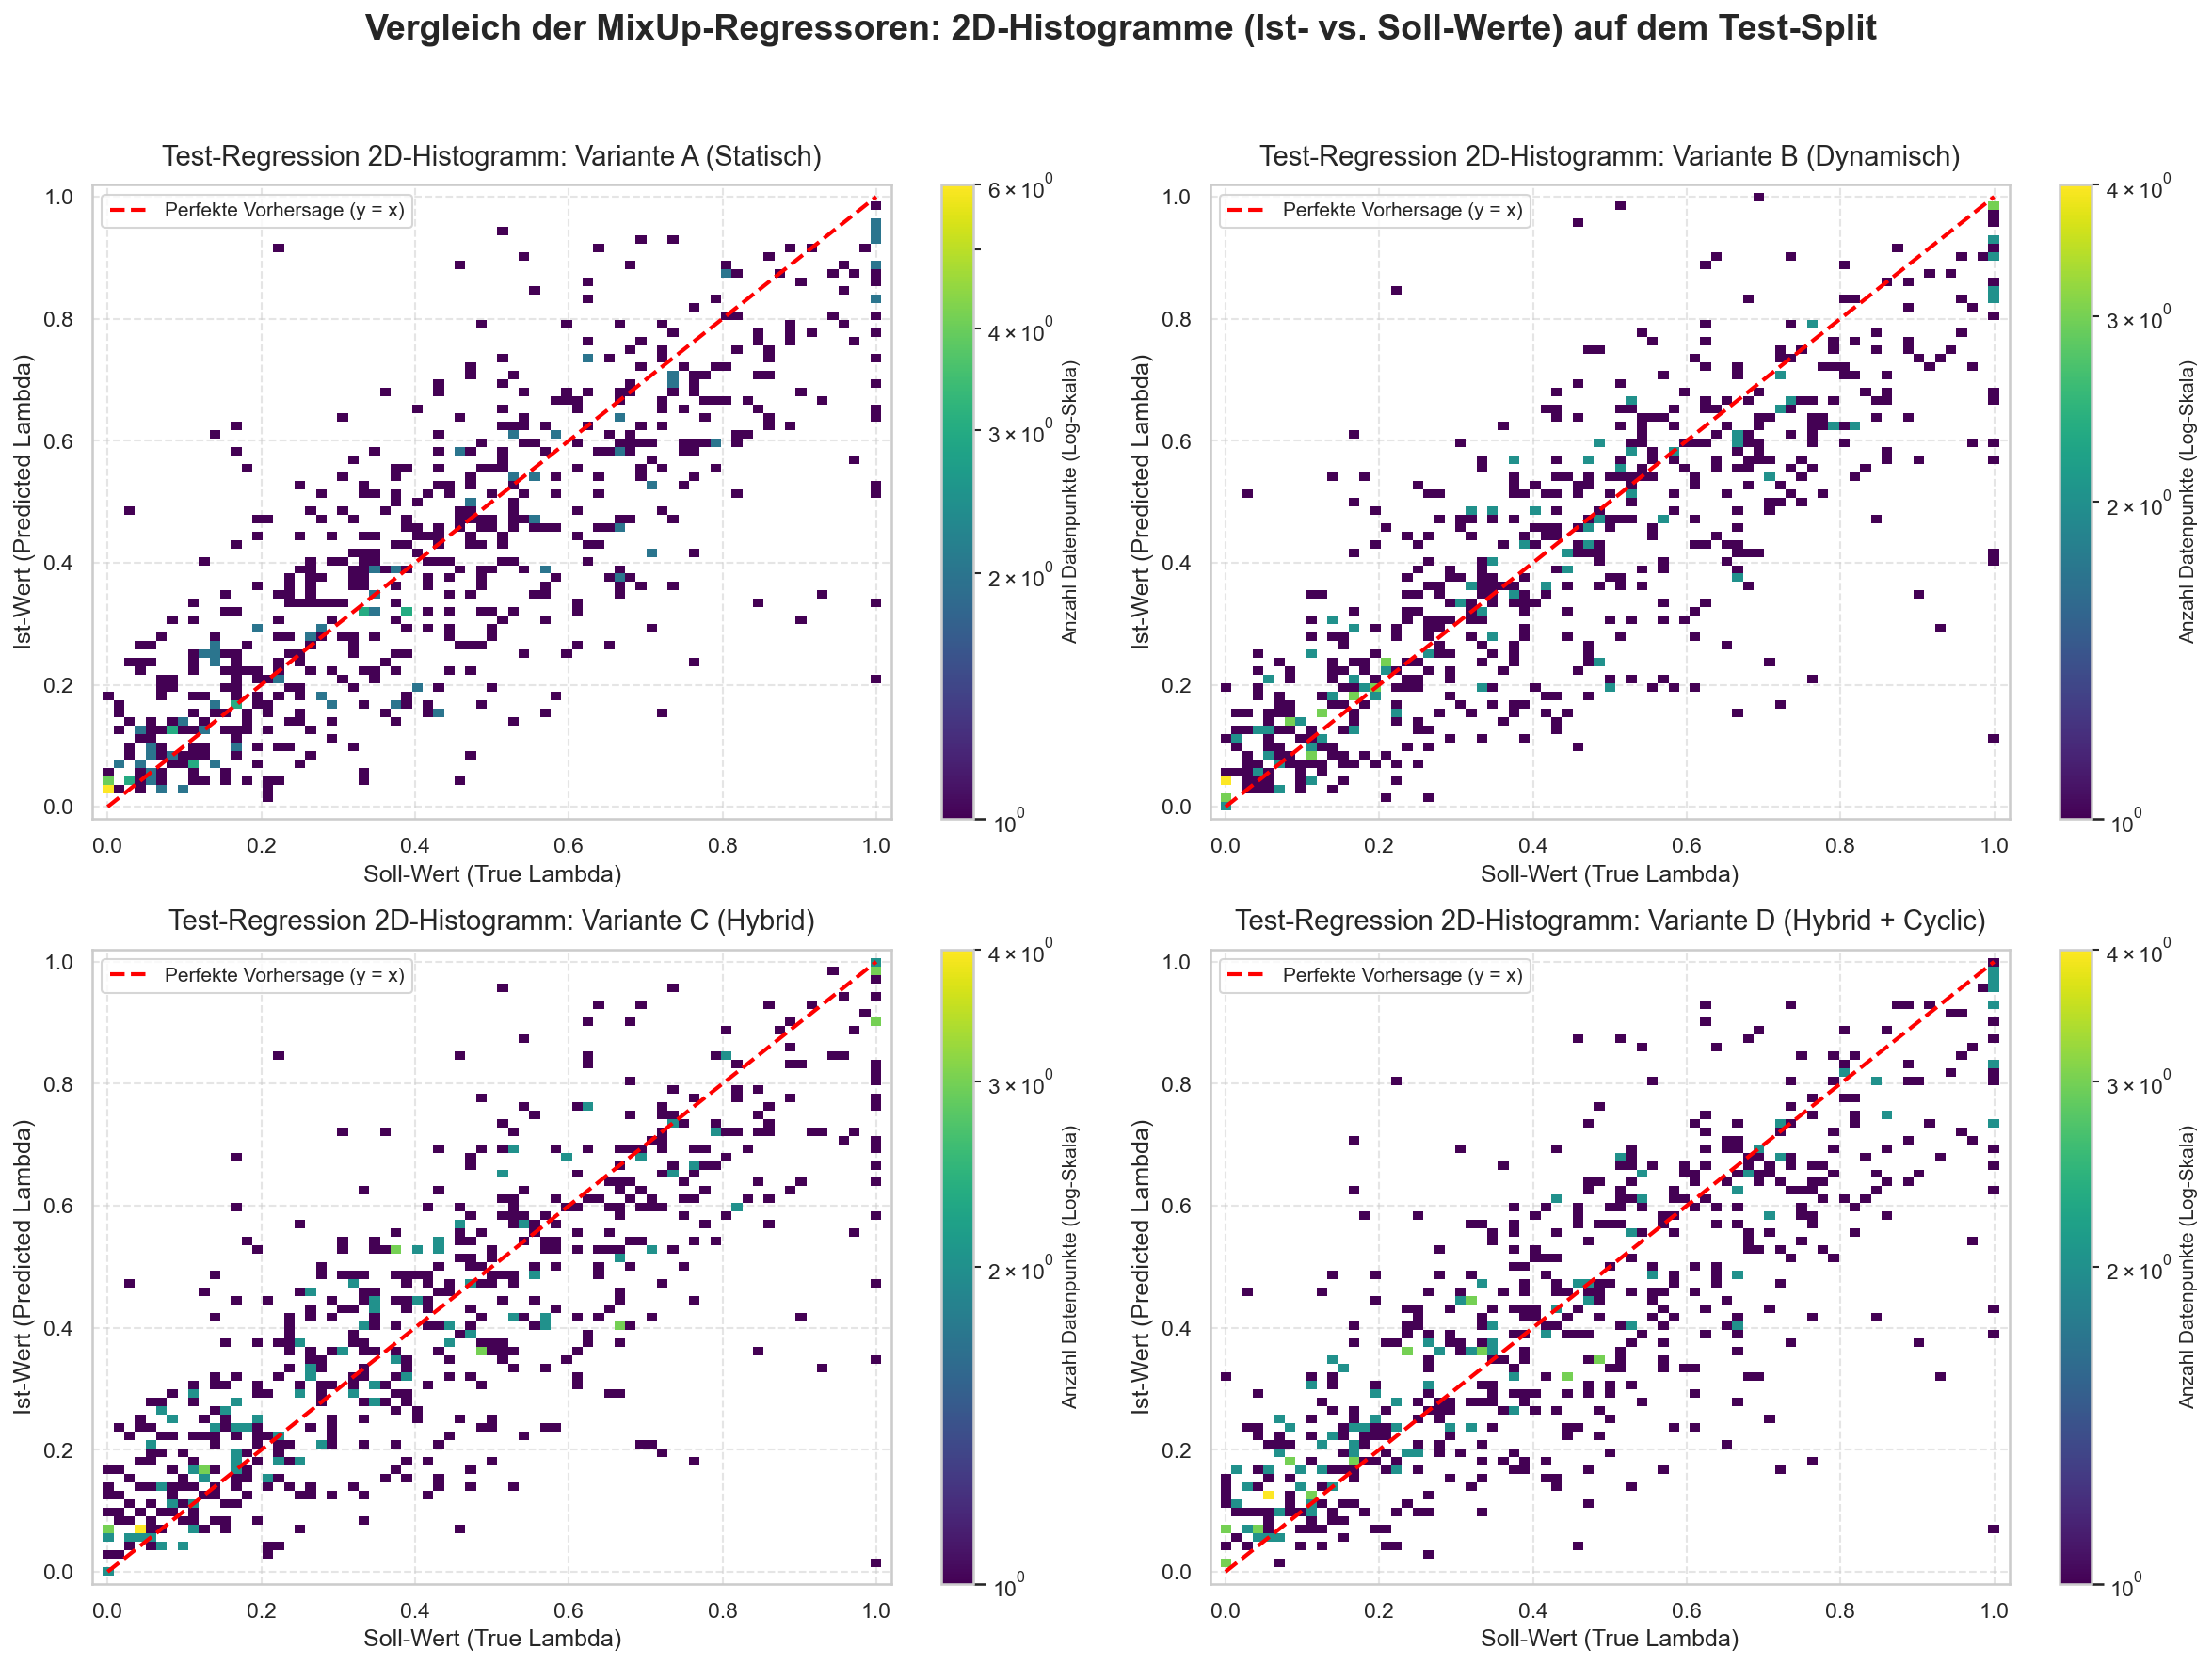

In [7]:
# 1.4. Visualisierung der Regression auf dem Test-Split (KDE-Dichte, Scatterplots und 2D-Histogramme)

# 1.4.1. KDE-Plot der Vorhersagen (gemischt) vs. True Targets
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(models_list):
    sub = df_test_reg[df_test_reg["model"] == model_name]
    if len(sub) > 0:
        sns.kdeplot(sub["predicted_target"], fill=True, color="purple", label="Modell-Vorhersagen (gemischt)", ax=axes[i], clip=(0.0, 1.0))
        sns.kdeplot(sub["true_target"], fill=False, color="orange", linestyle="--", linewidth=2.5, label="Wahre Test-Targets", ax=axes[i], clip=(0.0, 1.0))
        
    axes[i].set_title(f"Test-Regression Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Vorhersage- vs. Target-Verteilung auf dem gemischten Test-Split", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_test_regression_kde.png"), dpi=300)
plt.show()

# 1.4.2. Scatterplots Ist- vs. Soll-Wert
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(models_list):
    sub = df_test_reg[df_test_reg["model"] == model_name]
    if len(sub) > 0:
        axes[i].scatter(sub["true_target"], sub["predicted_target"], alpha=0.3, color="purple", edgecolors="none", s=15)
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    axes[i].set_title(f"Test-Regression Scatterplot: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=10, loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Ist- vs. Soll-Werte auf dem Test-Split", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_test_regression_scatterplot.png"), dpi=300)
plt.show()

# 1.4.3. 2D-Histogramme Ist- vs. Soll-Wert
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(models_list):
    sub = df_test_reg[df_test_reg["model"] == model_name]
    if len(sub) > 0:
        counts, xedges, yedges, im = axes[i].hist2d(
            sub["true_target"], sub["predicted_target"], bins=75, range=[[-0.02, 1.02], [-0.02, 1.02]],
            cmap="viridis", norm=mcolors.LogNorm(), cmin=1
        )
        cbar = fig.colorbar(im, ax=axes[i])
        cbar.set_label("Anzahl Datenpunkte (Log-Skala)", fontsize=10)
        
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    axes[i].set_title(f"Test-Regression 2D-Histogramm: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.02, 1.02)
    axes[i].set_ylim(-0.02, 1.02)
    axes[i].legend(fontsize=10, loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Vergleich der MixUp-Regressoren: 2D-Histogramme (Ist- vs. Soll-Werte) auf dem Test-Split", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_test_regression_hist2d.png"), dpi=300)
plt.show()


# 2. Auswertung auf dem Lebenshilfe-Datensatz (Out-of-Domain)


In [8]:
# 2.1. Binäre Klassifikationsevaluation auf dem Lebenshilfe-Set (LS = 1.0, AS = 0.0)
lh_table_rows = []
for _, row in df_summary.iterrows():
    lh_table_rows.append({
        "Modell": row["model"],
        "Ø Lambda (LS)": f"{float(row['lh_mean_lambda_ls']):.4f}",
        "Ø Lambda (AS)": f"{float(row['lh_mean_lambda_as']):.4f}",
        "Accuracy (Schwelle 0.5)": f"{float(row['lh_accuracy']) * 100:.2f}%",
        "Balanced Acc": f"{float(row['lh_balanced_acc']) * 100:.2f}%",
        "MAE (Target 1/0)": f"{float(row['lh_class_mae']):.4f}"
    })

df_lh_metrics = pd.DataFrame(lh_table_rows)
print("Klassifikationsergebnisse auf dem Lebenshilfe-Datensatz (Reine Sätze):")
display(df_lh_metrics)


Klassifikationsergebnisse auf dem Lebenshilfe-Datensatz (Reine Sätze):


,Modell,Ø Lambda (LS),Ø Lambda (AS),Accuracy (Schwelle 0.5),Balanced Acc,MAE (Target 1/0)
0,Variante A (Statisch),0.7012,0.0838,91.41%,91.82%,0.1988
1,Variante B (Dynamisch),0.7006,0.0725,93.56%,93.85%,0.1939
2,Variante C (Hybrid),0.7065,0.0859,91.59%,92.02%,0.1969
3,Variante D (Hybrid + Cyclic),0.7153,0.0909,94.10%,94.36%,0.1946


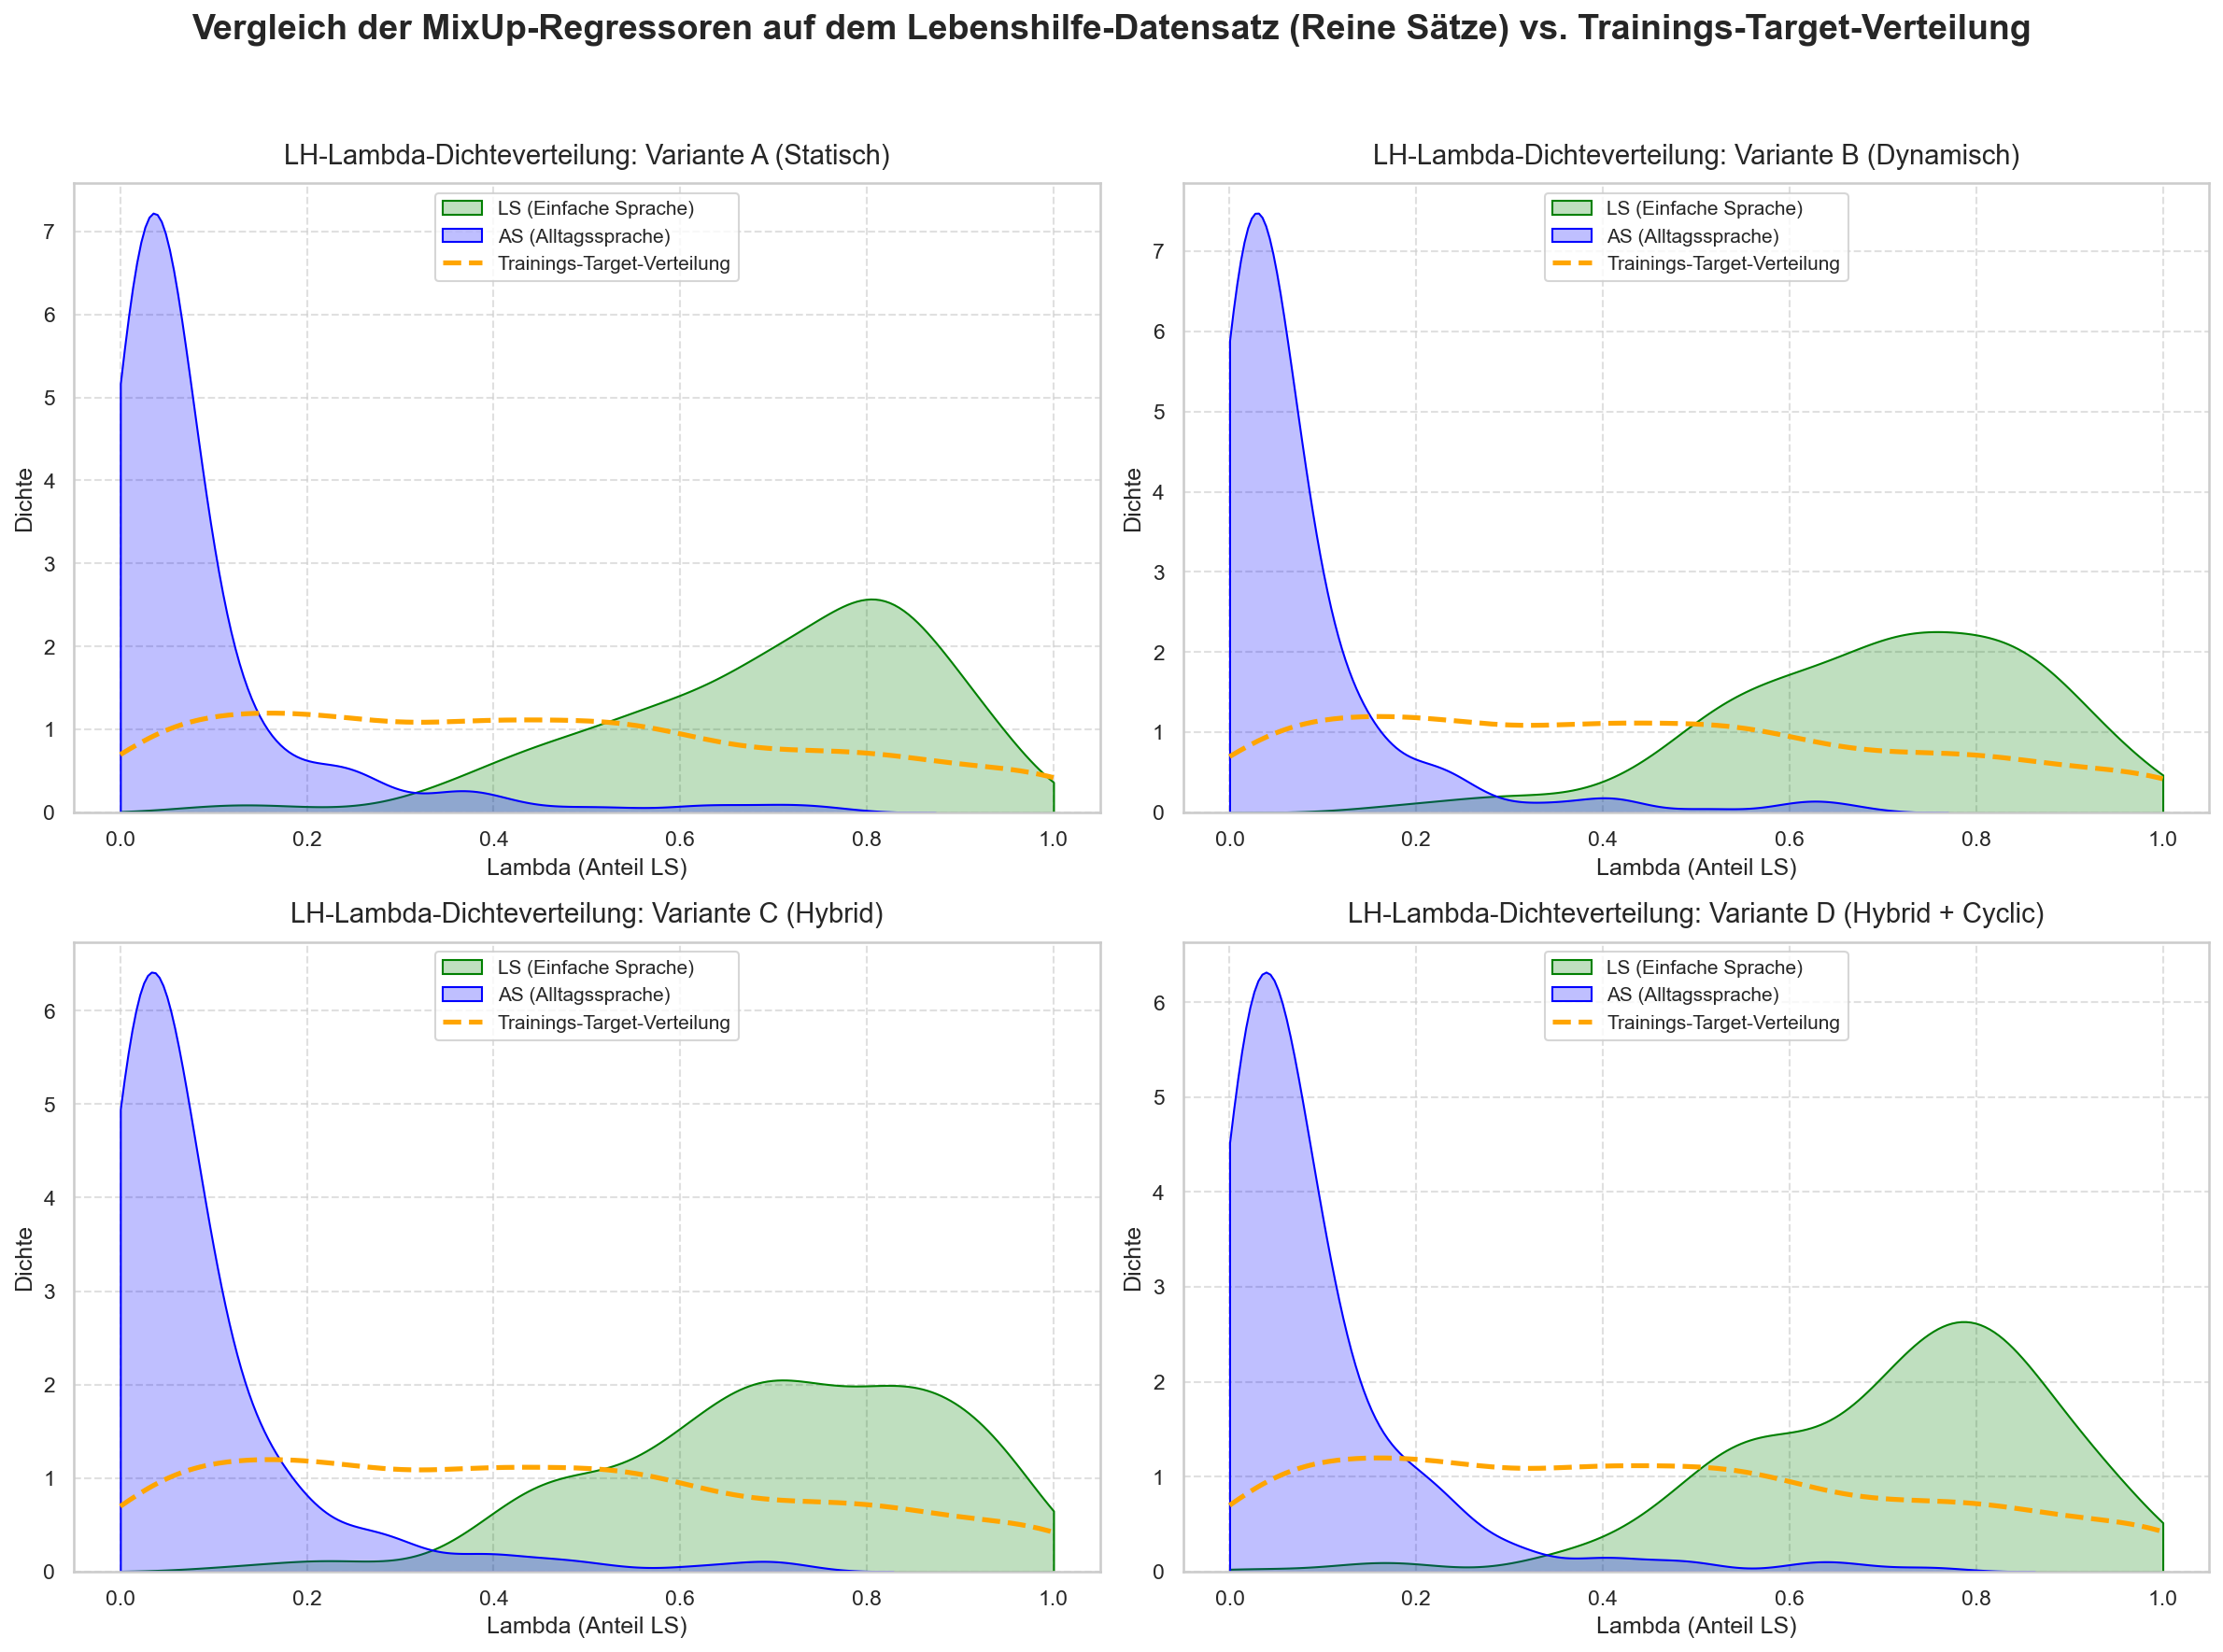

In [9]:
# 2.2. KDE-Plots (Dichteverteilungen) für die Klassifikation auf dem Lebenshilfe-Set
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models_list):
    sub_ls = df_lh_preds[(df_lh_preds["model"] == model_name) & (df_lh_preds["text_type"] == "LS")]["predicted_lambda"]
    sub_as = df_lh_preds[(df_lh_preds["model"] == model_name) & (df_lh_preds["text_type"] == "AS")]["predicted_lambda"]
    
    if len(sub_ls) > 0 and len(sub_as) > 0:
        sns.kdeplot(sub_ls, fill=True, color="green", label="LS (Einfache Sprache)", ax=axes[i], clip=(0.0, 1.0))
        sns.kdeplot(sub_as, fill=True, color="blue", label="AS (Alltagssprache)", ax=axes[i], clip=(0.0, 1.0))
    
    if train_targets is not None:
        sns.kdeplot(train_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Trainings-Target-Verteilung", ax=axes[i], clip=(0.0, 1.0))
        
    axes[i].set_title(f"LH-Lambda-Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren auf dem Lebenshilfe-Datensatz (Reine Sätze) vs. Trainings-Target-Verteilung", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_lh_classification_kde.png"), dpi=300)
plt.show()


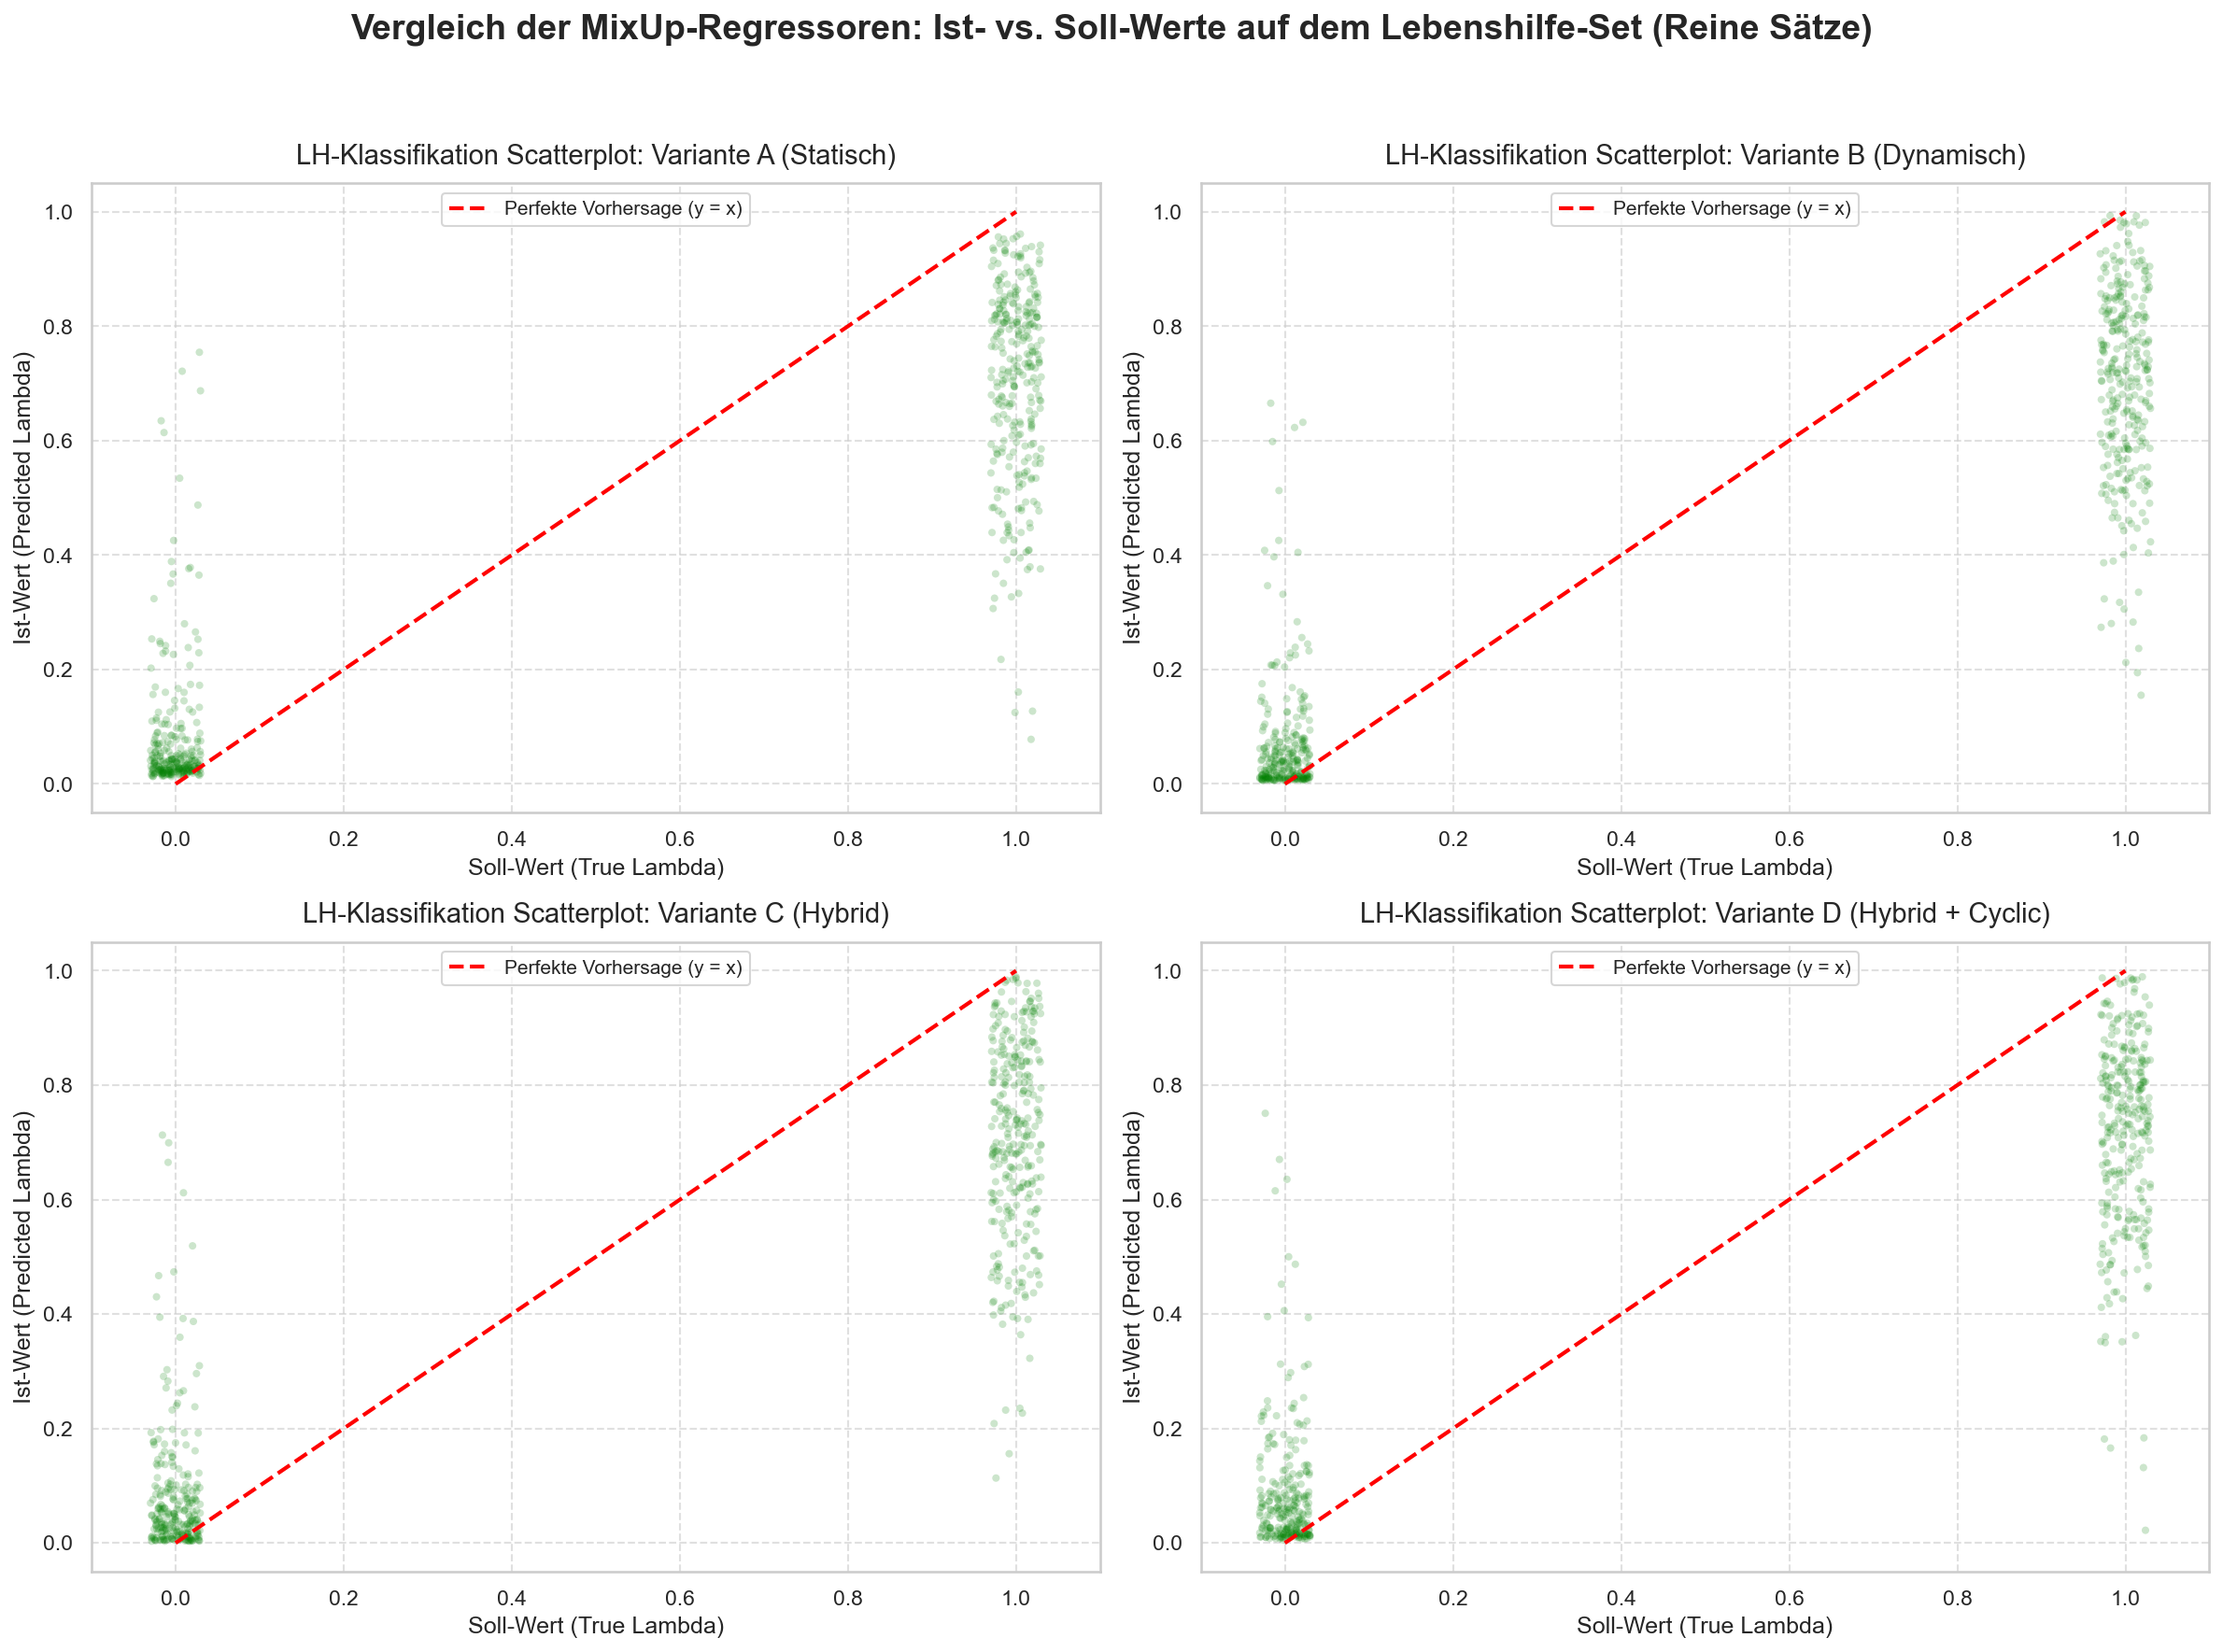

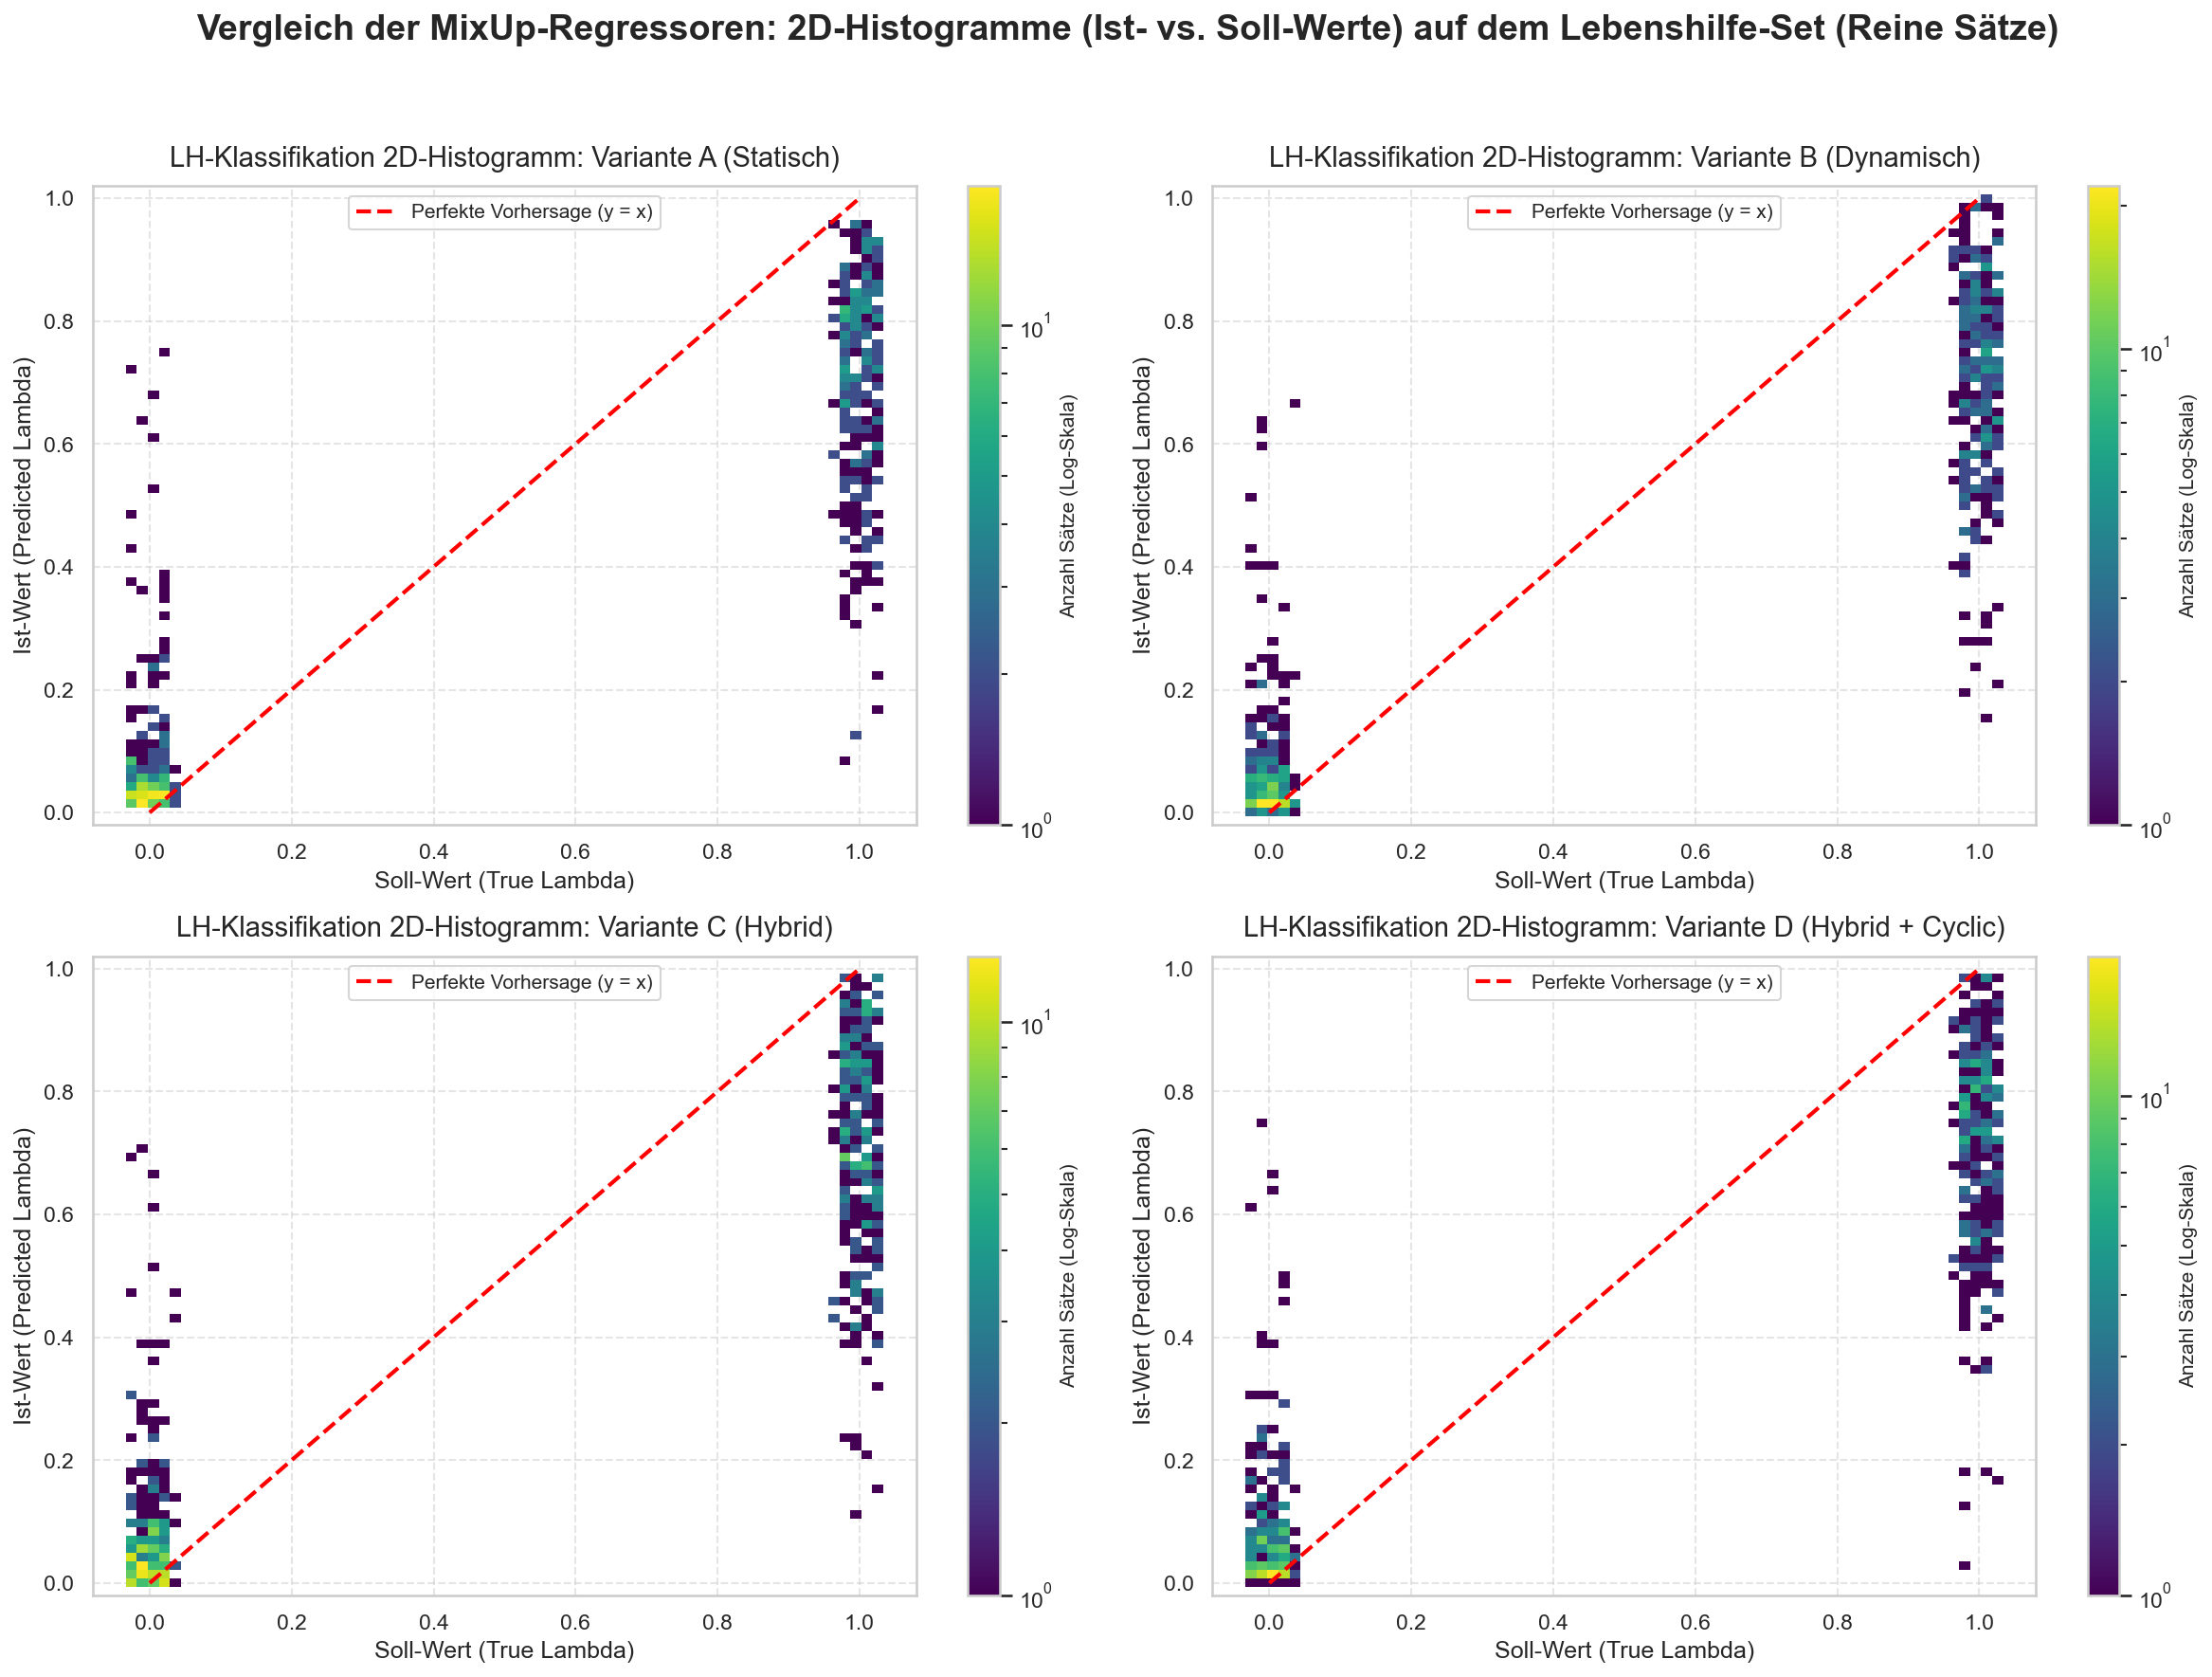

In [10]:
# 2.2.5. Scatterplots (Ist- vs. Soll-Wert) für die Klassifikation (reine Sätze) auf dem Lebenshilfe-Set
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models_list):
    sub = df_lh_preds[df_lh_preds["model"] == model_name]
    if len(sub) > 0:
        jitter = np.random.uniform(-0.03, 0.03, len(sub))
        axes[i].scatter(sub["true_label"] + jitter, sub["predicted_lambda"], alpha=0.2, color="green", edgecolors="none", s=15)
        
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    axes[i].set_title(f"LH-Klassifikation Scatterplot: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.1, 1.1)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Ist- vs. Soll-Werte auf dem Lebenshilfe-Set (Reine Sätze)", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_lh_classification_scatterplot.png"), dpi=300)
plt.show()

# 2.2.6. 2D-Histogramme (Ist- vs. Soll-Wert) für die Klassifikation (reine Sätze) auf dem Lebenshilfe-Set
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models_list):
    sub = df_lh_preds[df_lh_preds["model"] == model_name]
    if len(sub) > 0:
        jitter = np.random.uniform(-0.03, 0.03, len(sub))
        counts, xedges, yedges, im = axes[i].hist2d(
            sub["true_label"] + jitter, sub["predicted_lambda"], bins=75, range=[[-0.08, 1.08], [-0.02, 1.02]],
            cmap="viridis", norm=mcolors.LogNorm(), cmin=1
        )
        cbar = fig.colorbar(im, ax=axes[i])
        cbar.set_label("Anzahl Sätze (Log-Skala)", fontsize=10)
        
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    axes[i].set_title(f"LH-Klassifikation 2D-Histogramm: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.08, 1.08)
    axes[i].set_ylim(-0.02, 1.02)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Vergleich der MixUp-Regressoren: 2D-Histogramme (Ist- vs. Soll-Werte) auf dem Lebenshilfe-Set (Reine Sätze)", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_lh_classification_hist2d.png"), dpi=300)
plt.show()


In [11]:
# 2.3. Regressionsevaluation auf dem Lebenshilfe-Set (Mixup / Shuffled)
lh_reg_rows = []
for _, row in df_summary.iterrows():
    lh_reg_rows.append({
        "Modell": row["model"],
        "LH MSE (Regression)": f"{float(row['lh_reg_mse']):.4f}",
        "LH MAE (Regression)": f"{float(row['lh_reg_mae']):.4f}"
    })

df_lh_reg_metrics = pd.DataFrame(lh_reg_rows)
print("Regressionsergebnisse auf dem Lebenshilfe-Datensatz (Mixup):")
display(df_lh_reg_metrics)


Regressionsergebnisse auf dem Lebenshilfe-Datensatz (Mixup):


,Modell,LH MSE (Regression),LH MAE (Regression)
0,Variante A (Statisch),0.0466,0.1705
1,Variante B (Dynamisch),0.0493,0.1724
2,Variante C (Hybrid),0.0469,0.1668
3,Variante D (Hybrid + Cyclic),0.0451,0.1656


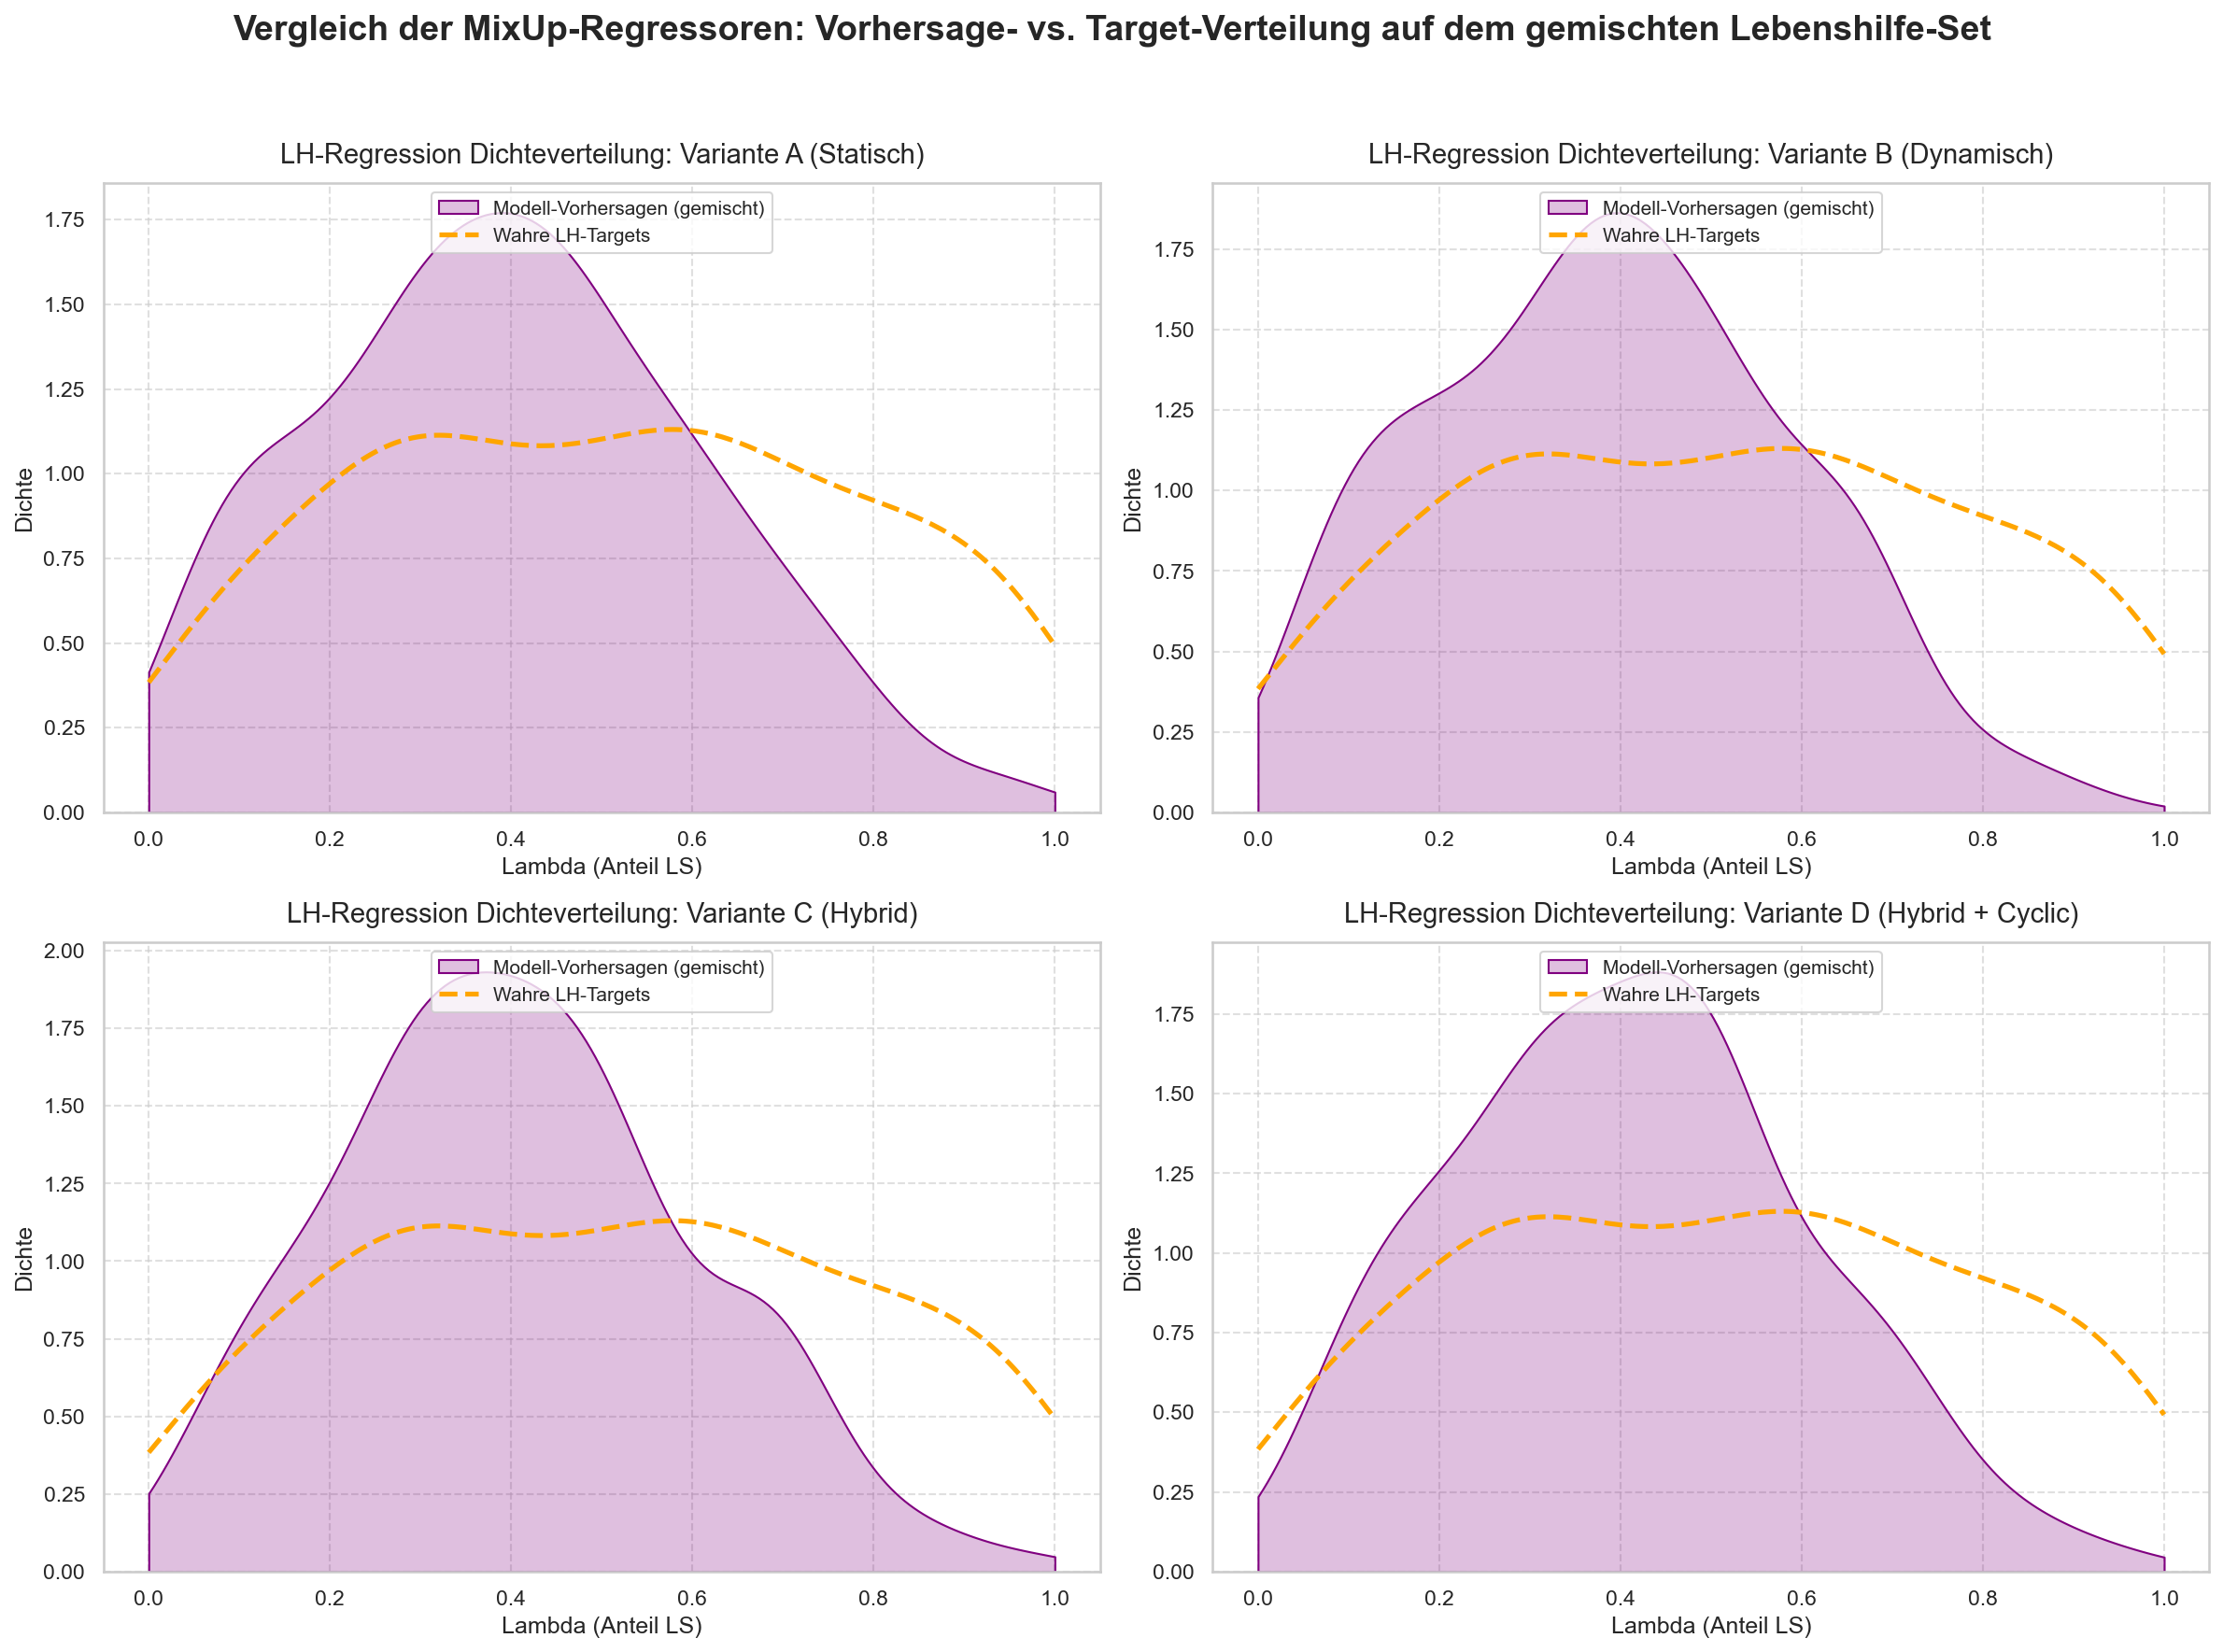

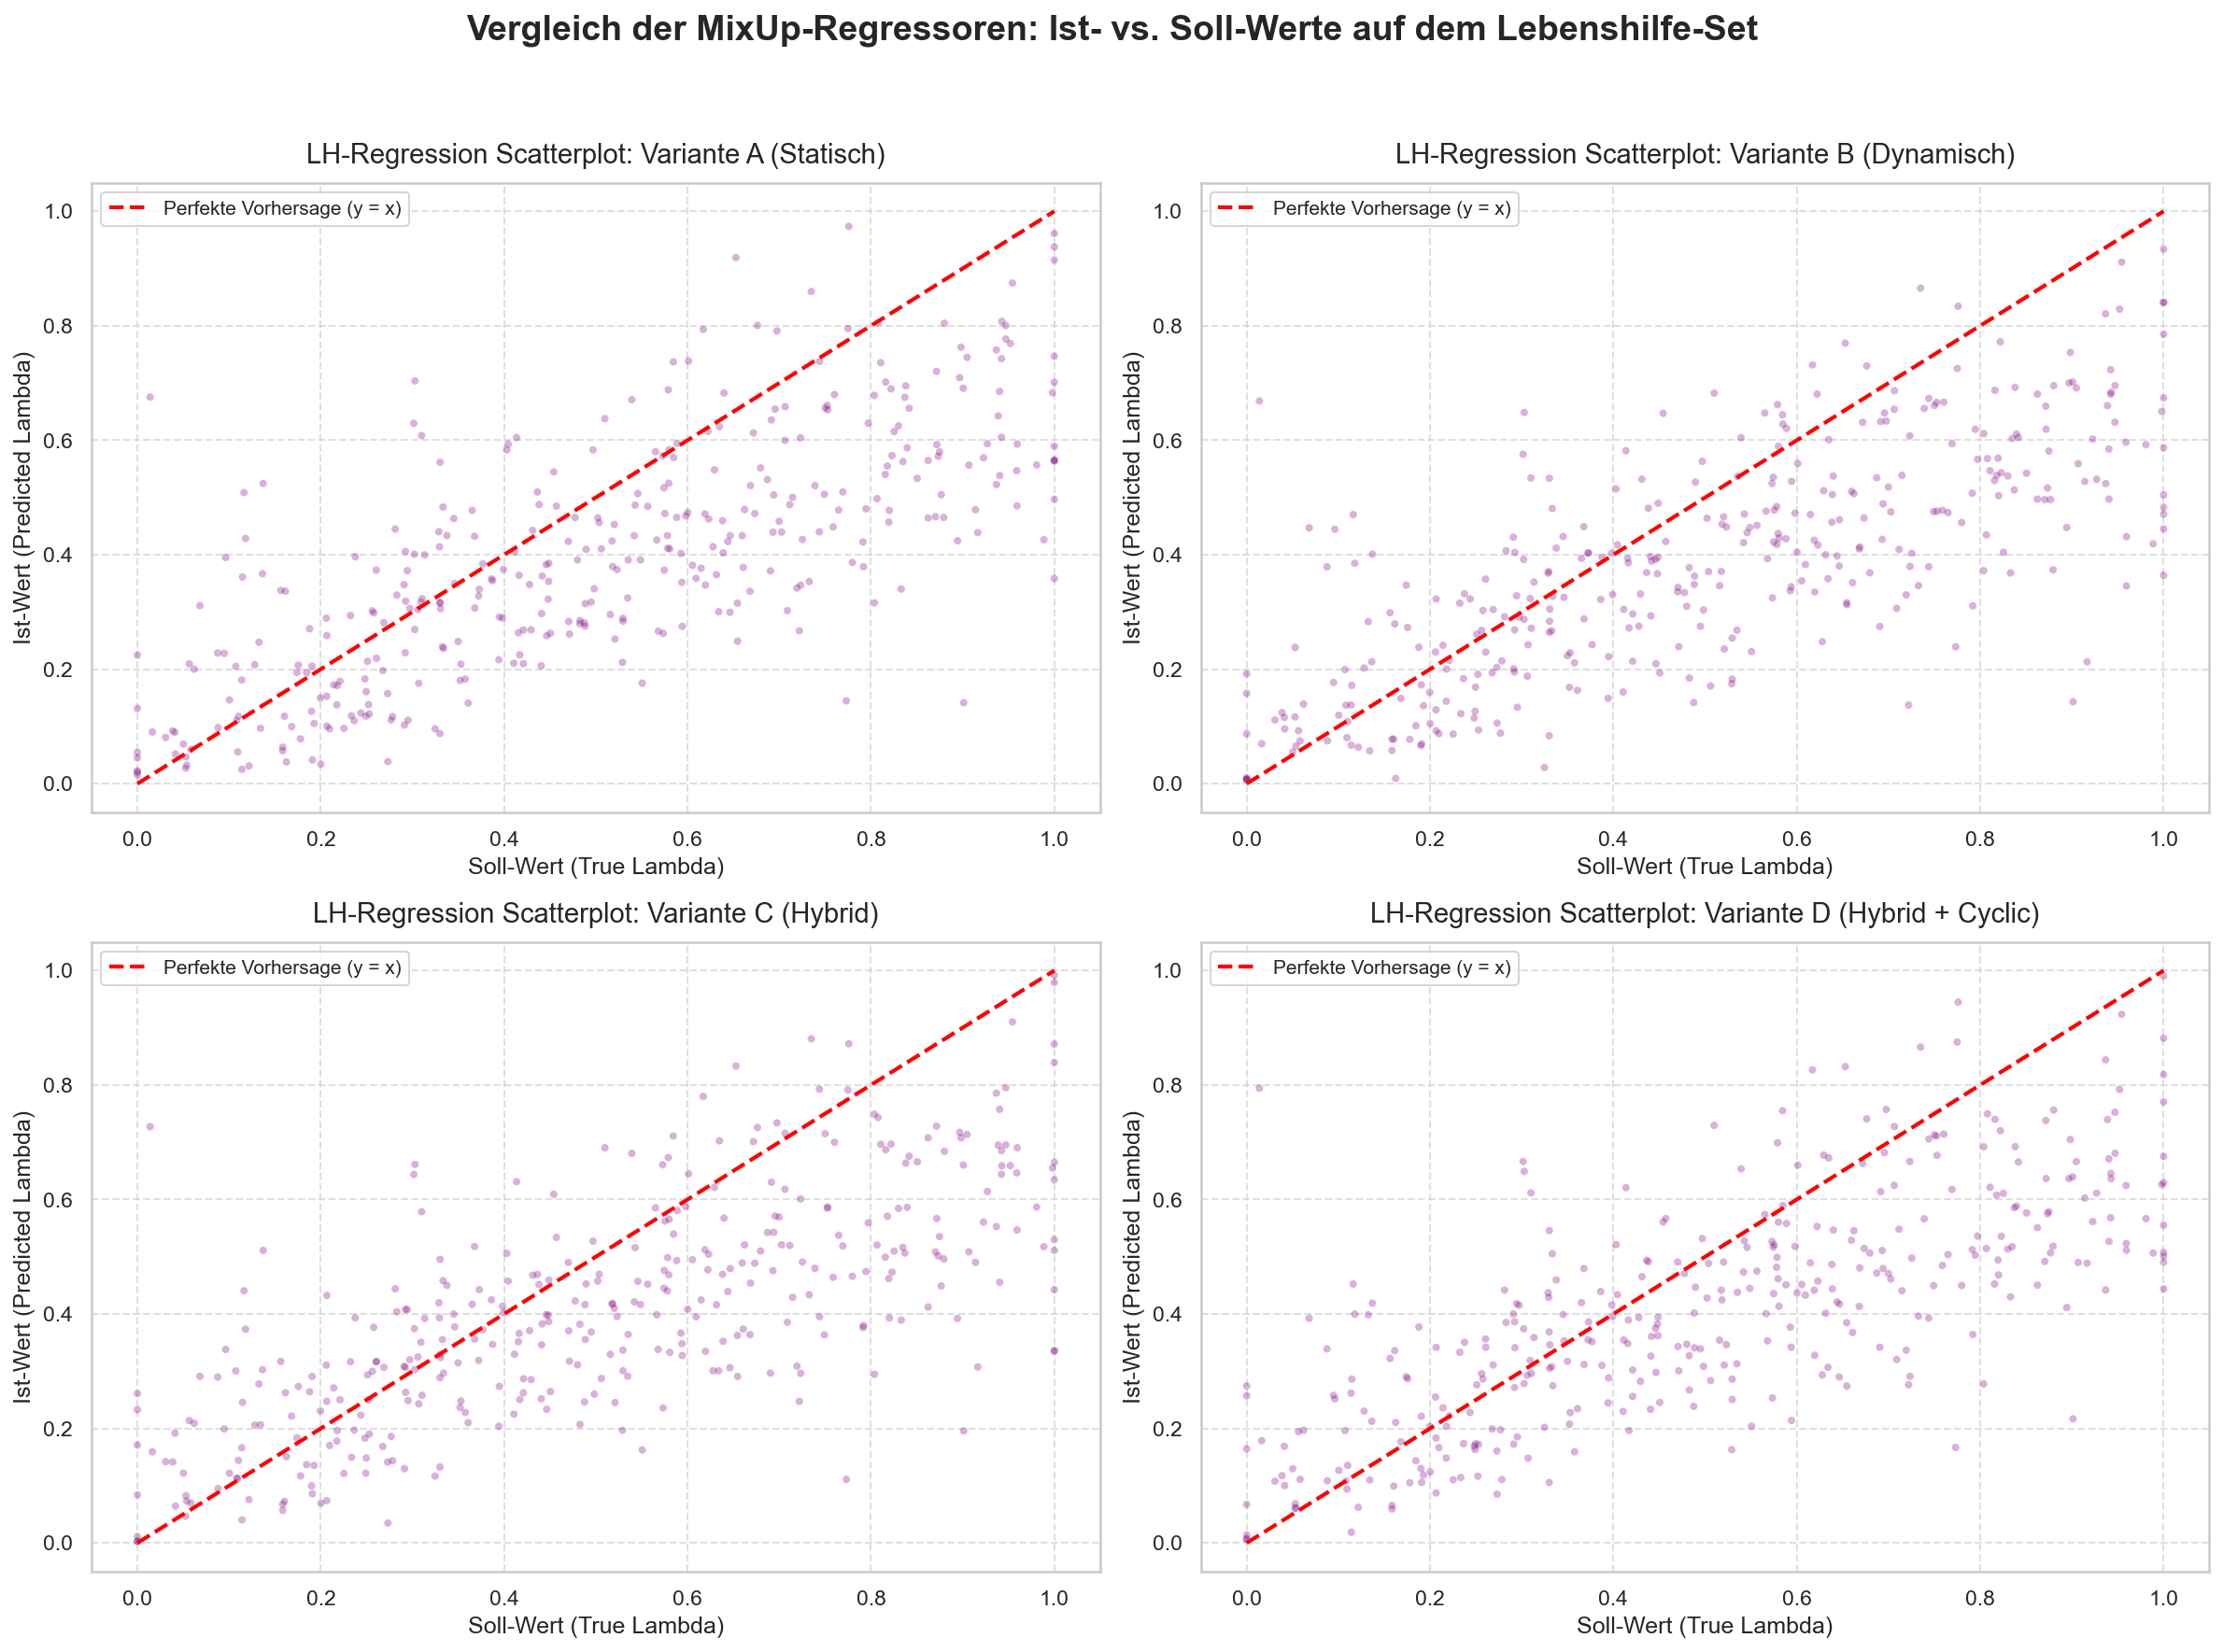

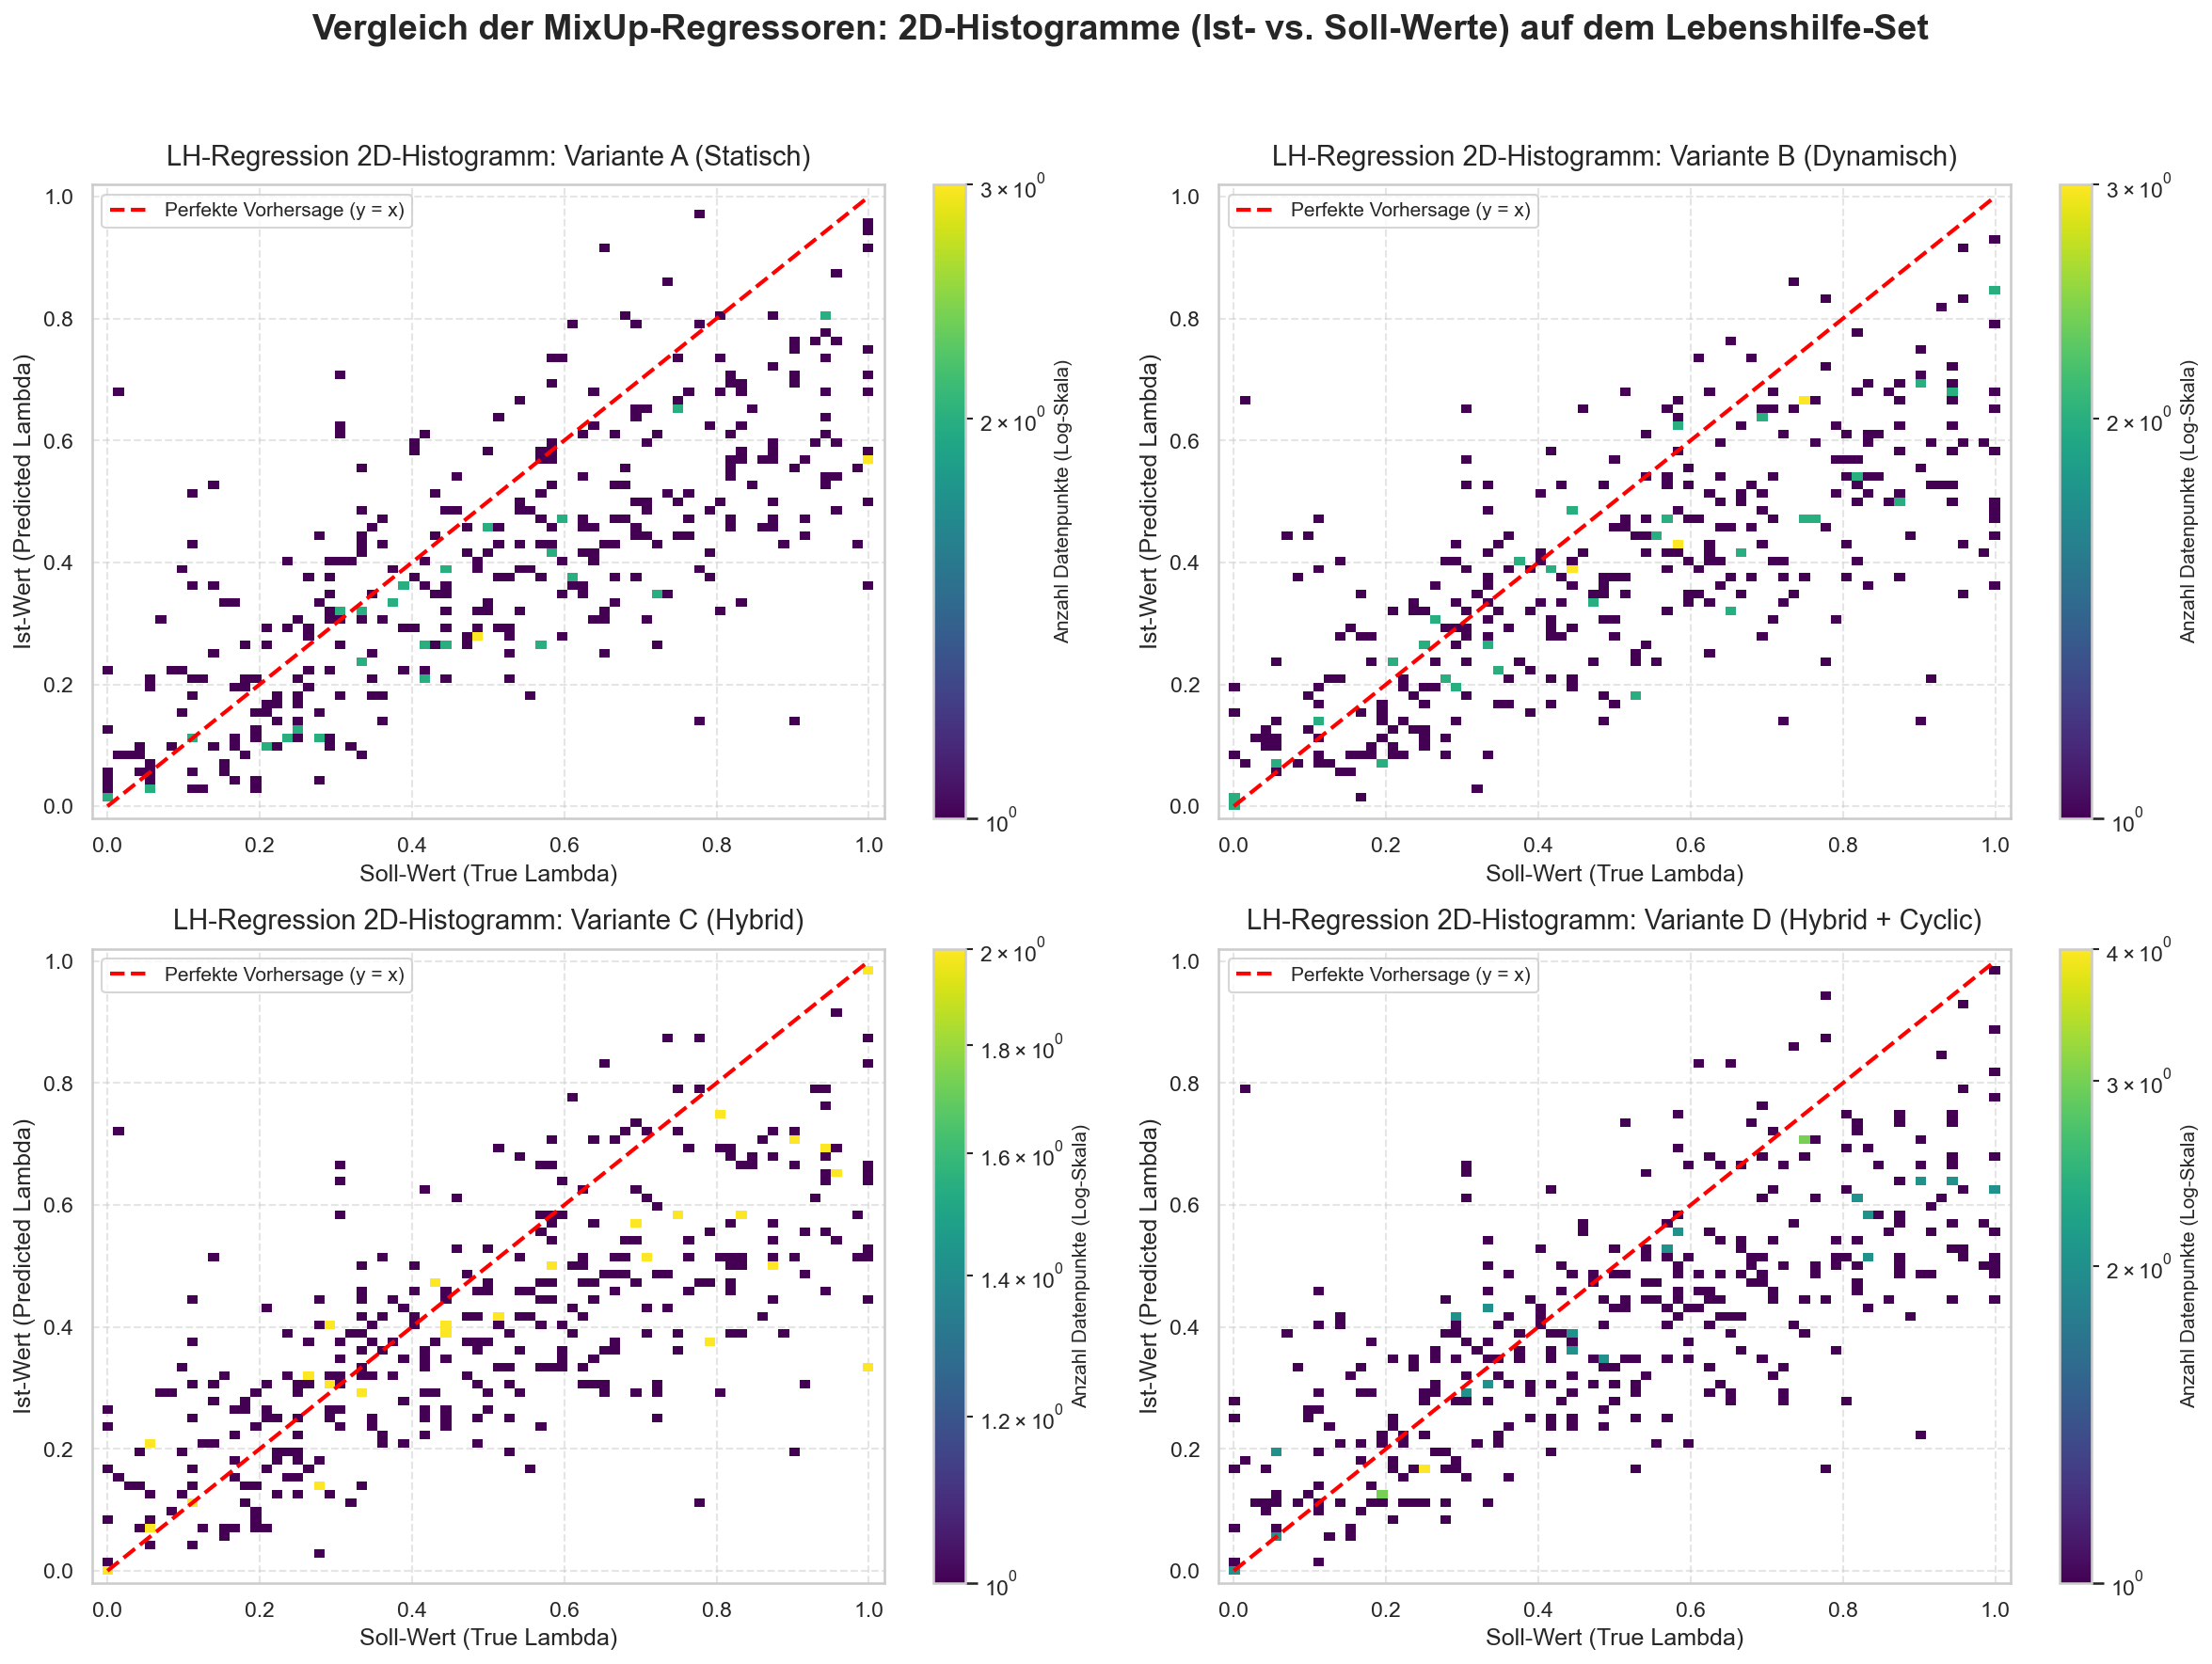

In [12]:
# 2.4. Visualisierung der Regression auf dem Lebenshilfe-Set (KDE-Dichte, Scatterplots und 2D-Histogramme)

# 2.4.1. KDE-Plot der Vorhersagen (gemischt) vs. True Targets
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(models_list):
    sub = df_lh_reg[df_lh_reg["model"] == model_name]
    if len(sub) > 0:
        sns.kdeplot(sub["predicted_target"], fill=True, color="purple", label="Modell-Vorhersagen (gemischt)", ax=axes[i], clip=(0.0, 1.0))
        sns.kdeplot(sub["true_target"], fill=False, color="orange", linestyle="--", linewidth=2.5, label="Wahre LH-Targets", ax=axes[i], clip=(0.0, 1.0))
        
    axes[i].set_title(f"LH-Regression Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Vorhersage- vs. Target-Verteilung auf dem gemischten Lebenshilfe-Set", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_lh_regression_kde.png"), dpi=300)
plt.show()

# 2.4.2. Scatterplots Ist- vs. Soll-Wert
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(models_list):
    sub = df_lh_reg[df_lh_reg["model"] == model_name]
    if len(sub) > 0:
        axes[i].scatter(sub["true_target"], sub["predicted_target"], alpha=0.3, color="purple", edgecolors="none", s=15)
        
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    axes[i].set_title(f"LH-Regression Scatterplot: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=10, loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Ist- vs. Soll-Werte auf dem Lebenshilfe-Set", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_lh_regression_scatterplot.png"), dpi=300)
plt.show()

# 2.4.3. 2D-Histogramme Ist- vs. Soll-Wert
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
for i, model_name in enumerate(models_list):
    sub = df_lh_reg[df_lh_reg["model"] == model_name]
    if len(sub) > 0:
        counts, xedges, yedges, im = axes[i].hist2d(
            sub["true_target"], sub["predicted_target"], bins=75, range=[[-0.02, 1.02], [-0.02, 1.02]],
            cmap="viridis", norm=mcolors.LogNorm(), cmin=1
        )
        cbar = fig.colorbar(im, ax=axes[i])
        cbar.set_label("Anzahl Datenpunkte (Log-Skala)", fontsize=10)
        
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    axes[i].set_title(f"LH-Regression 2D-Histogramm: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.02, 1.02)
    axes[i].set_ylim(-0.02, 1.02)
    axes[i].legend(fontsize=10, loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Vergleich der MixUp-Regressoren: 2D-Histogramme (Ist- vs. Soll-Werte) auf dem Lebenshilfe-Set", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(REPO_ROOT, "results/plots/experiments/mixup_variants/mixup_lh_regression_hist2d.png"), dpi=300)
plt.show()
